2023-12-08 17:15:34,359 - INFO - tvb_multiscale.tvb_nest.config - Configuring NEST path...
2023-12-08 17:15:34,359 - INFO - tvb_multiscale.tvb_nest.config - Configuring NEST path...
2023-12-08 17:15:34,361 - INFO - tvb_multiscale.tvb_nest.config - NEST_INSTALL_DIR: /home/docker/build/nest
2023-12-08 17:15:34,361 - INFO - tvb_multiscale.tvb_nest.config - NEST_INSTALL_DIR: /home/docker/build/nest
2023-12-08 17:15:34,361 - INFO - tvb_multiscale.tvb_nest.config - NEST_DATA_DIR: /home/docker/build/nest/share/nest
2023-12-08 17:15:34,361 - INFO - tvb_multiscale.tvb_nest.config - NEST_DATA_DIR: /home/docker/build/nest/share/nest
2023-12-08 17:15:34,362 - INFO - tvb_multiscale.tvb_nest.config - NEST_DOC_DIR: /home/docker/build/nest/share/doc/nest
2023-12-08 17:15:34,362 - INFO - tvb_multiscale.tvb_nest.config - NEST_DOC_DIR: /home/docker/build/nest/share/doc/nest
2023-12-08 17:15:34,363 - INFO - tvb_multiscale.tvb_nest.config - NEST_MODULE_PATH: /home/docker/build/nest/lib/nest
2023-12-08 17:1

Outputs' path: /home/docker/packages/tvb-multiscale/rising_net/working_files/s1stim_stimbase10_stim5_nsd0
Config (
  title ........................................................................................... 'Config gid: 3c67080f-e217-4f71-818d-87fc18c1e4d7'
  Type ............................................................................................ 'Config'
  gid ............................................................................................. UUID('3c67080f-e217-4f71-818d-87fc18c1e4d7')
  config.gid ...................................................................................... UUID('3c67080f-e217-4f71-818d-87fc18c1e4d7')
  config.title .................................................................................... 'Config gid: 3c67080f-e217-4f71-818d-87fc18c1e4d7'
  config.log ...................................................................................... <Logger tvb_multiscale.tvb_nest.config (DEBUG)>
  config.BASEPATH ..................

<Figure size 432x288 with 0 Axes>

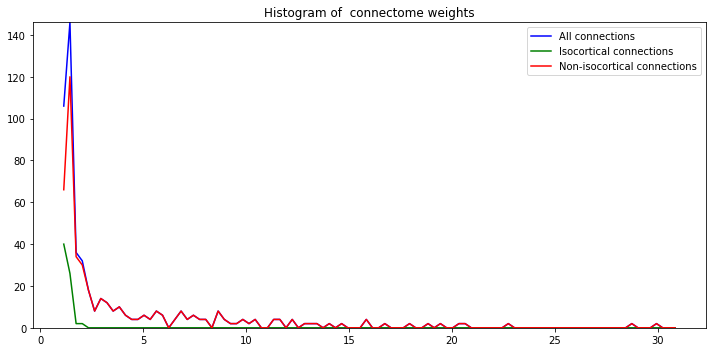

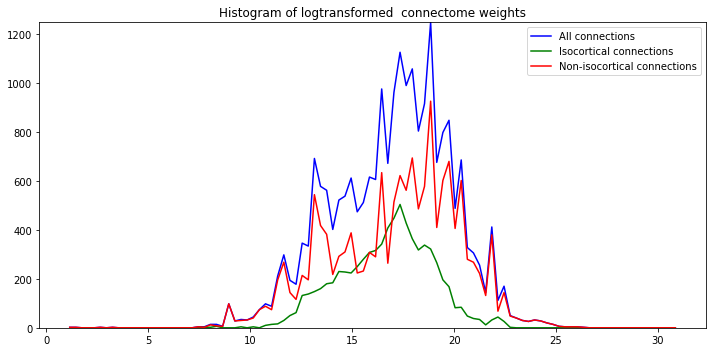

In [1]:
from rising_net.scripts.tvb_nest_script import *
from rising_net.scripts.nest_script import *        #build_NEST_network, plot_nest_results

from tvb_multiscale.core.plot.plotter import Plotter

from tvb.contrib.scripts.datatypes.time_series_xarray import TimeSeriesRegion as TimeSeriesXarray



# Assuming:
# DEFAULT_ARGS = {'G': 6.0, 'STIMULUS': 0.1, 'STIMULUS_BASELINE': 0.0,
#                 'I_e': -0.35, 'I_s': 0.085,
#                 'w_ie': -3.0, 'w_rs': -2.0,
#                 'CONN_LOG': True, 'FIC': 1.11,  'FIC_SPLIT': 0.31,  #'fit',
#                 'PRIORS_DIST': 'uniform',
#                 'output_folder': "", 'verbose': 1, 'plot_flag': True}

# config.TRANSIENT_RATIO =0.25
# # TVB - NEST interface parameters:
# config.MOSSY_MAX_RATE = 122.0  # Hz
# config.w_TVB_to_NEST = 0.04

kwargs = {"FIC": 0.0,
          "G": 1.0, 
          "pathway_gain": 1.0, 
          "STIMULUS": 0.5, 
          "STIMULUS_BASELINE": 1.0}


pathway_gain = kwargs.pop("pathway_gain", 1.0)
pathway_mode = kwargs.pop("pathway_mode", "task")
STIMULUS = kwargs.get("STIMULUS", 0.1)
STIMULUS_BASELINE = kwargs.get("STIMULUS_BASELINE", 0.1)

cn_to_s1brlthal = kwargs.pop("cn_to_s1brlthal", True)
hemispheres = int(kwargs.pop("hemispheres", -1))

seed = int(kwargs.pop("seed", 0))
test_name = 's1stim'              # "s1stim", "s1m1stim", "trigs1stim", "trigs1m1stim"
if test_name.find("trig") > -1:
    TRIGEMINAL = True
else:
    TRIGEMINAL = False
    
if test_name.find("m1") > -1:
    M1STIM = True
else:
    M1STIM = False

resfilename = "%s_stimbase%d_stim%d_nsd%d" % (test_name, int(10*STIMULUS_BASELINE), int(10*STIMULUS), seed)
path = os.path.join(os.getcwd(), resfilename)
# Get configuration
config, plotter = configure(output_folder=path, verbose=2, **kwargs) # 
config.SIMULATION_LENGTH = 10000.0
config.RANDOM_SEED_TVB = seed
config.RANDOM_SEED_NEST = seed
config.STIMULUS_RATE = 8.0 

# Load and prepare connectome and connectivity with all possible normalizations:
connectome, major_structs_labels, voxel_count, inds, maps = prepare_connectome(config, plotter=plotter)
connectivity = build_connectivity(connectome, inds, config, 
                                  hemispheres=hemispheres, 
                                  cereb_nuclei_to_s1thal=True, 
                                  trigeminal_to_m1thal=TRIGEMINAL and M1STIM)



In [2]:
connectivity.weights[inds["trigeminal"]].sum(axis=1)

array([87.0972721, 87.0972721])

In [3]:
connectivity.weights[inds["trigeminal"]] = 0.0
if not TRIGEMINAL:
    connectivity.weights[:, inds["trigeminal"]] = 0.0
    
# Keep only the spinal trigeminal and M1 and S1 barrel field and their specific thalami.
# Maintain the total indegree, though.
indegree = {}
taskinds = []
regs = ["m1", "s1brl", "m1thal", "s1brlthal", "trigeminal"]
for reg in regs:
    for iH, hemi in zip([0, 1], ["right_", "left_"]):
        indegree[hemi + reg] = connectivity.weights[inds[reg][iH]].sum()
    taskinds += inds[reg].tolist()
taskinds = np.sort(taskinds)

def newind(ind, inds):
    return inds.tolist().index(ind)

connectivity.region_labels = connectivity.region_labels[taskinds]
connectivity.centres = connectivity.centres[taskinds]
# connectivity.orientations = connectivity.orientations[taskinds]
# connectivity.areas = connectivity.areas[taskinds]
connectivity.hemispheres = connectivity.hemispheres[taskinds]
# connectivity.cortical = connectivity.cortical[taskinds]
connectivity.weights = connectivity.weights[taskinds][:, taskinds]
connectivity.tract_lengths = connectivity.tract_lengths[taskinds][:, taskinds]
connectivity.configure()

newinds = {}
newtaskinds = []
for reg in regs:
    newinds[reg] = []
    for iH, hemi in zip([0, 1], ["right_", "left_"]):
        ind = newind(inds[reg][iH], taskinds)
        if ("thal" not in reg or "w" not in config.THAL_CRTX_FIX) and indegree[hemi + reg] > 0.0:
            if reg in ["m1", "s1brl"] and "w" in config.THAL_CRTX_FIX:
                connectivity.weights[ind] *= (indegree[hemi + reg] -1.0) / (connectivity.weights[ind].sum() - 1.0)
            else:
                connectivity.weights[ind] *= indegree[hemi + reg] / connectivity.weights[ind].sum()
                assert np.isclose(connectivity.weights[ind].sum(), indegree[hemi + reg])
        newtaskinds.append(ind)
        newinds[reg].append(ind)
    newinds[reg] = np.sort(newinds[reg])
newtaskinds = np.sort(newtaskinds)
newinds["m1s1brl"] =  np.sort(np.concatenate([newinds["m1"], newinds["s1brl"]]))
newinds["crtx"] = newinds["m1s1brl"]
newinds["thalspec"] = np.sort(np.concatenate([newinds["m1thal"], newinds["s1brlthal"]]))
newinds["subcrtx"] = np.sort(np.concatenate([newinds["thalspec"], 
                                             newinds["trigeminal"] if TRIGEMINAL else []])).astype('i')
newinds['crtx_and_subcrtx'] = np.sort(np.concatenate([newinds["crtx"], 
                                                     newinds["trigeminal"] if TRIGEMINAL else []])).astype('i')
newinds["motor"] = np.sort(np.concatenate([newinds["m1"], newinds["m1thal"],
                                          newinds["trigeminal"] if TRIGEMINAL else []])).astype('i')
newinds["sens"] = np.sort(np.concatenate([newinds["s1brl"], newinds["s1brlthal"], 
                                          newinds["trigeminal"] if TRIGEMINAL else []])).astype('i')
newinds["cereb"] = []
newinds["ansilob"] = []
newinds["facial"] = []

newmaps = {}
newmaps["is_cortical"] = np.array([False] * connectivity.number_of_regions).astype("bool")
newmaps["is_cortical"][newinds["crtx"]] = True
newmaps["is_thalamic"] = np.array([False] * connectivity.number_of_regions).astype("bool")
newmaps["is_thalamic"][newinds["thalspec"]] = True
newmaps["is_subcortical"] = np.logical_not(newmaps["is_cortical"])
newmaps["is_subcortical_not_thalspec"] = np.array([False] * connectivity.number_of_regions).astype("bool")
newmaps["is_subcortical_not_thalspec"][newinds["trigeminal"]] = True
newinds["subcrtx_not_thalspec"] = np.where(newmaps["is_subcortical_not_thalspec"])[0].astype('i')

if "w" in config.THAL_CRTX_FIX:
    connectivity.weights[newinds["crtx"], newinds["thalspec"]] = 1.0

In [4]:
display(newinds)

{'m1': array([0, 5]),
 's1brl': array([1, 6]),
 'm1thal': array([2, 7]),
 's1brlthal': array([3, 8]),
 'trigeminal': array([4, 9]),
 'm1s1brl': array([0, 1, 5, 6]),
 'crtx': array([0, 1, 5, 6]),
 'thalspec': array([2, 3, 7, 8]),
 'subcrtx': array([2, 3, 7, 8], dtype=int32),
 'crtx_and_subcrtx': array([0, 1, 5, 6], dtype=int32),
 'motor': array([0, 2, 5, 7], dtype=int32),
 'sens': array([1, 3, 6, 8], dtype=int32),
 'cereb': [],
 'ansilob': [],
 'facial': [],
 'subcrtx_not_thalspec': array([4, 9], dtype=int32)}

In [5]:
config.model_params

OrderedDict([('G', 1.0),
             ('STIMULUS', 0.5),
             ('I_e', -0.35),
             ('I_s', 0.085),
             ('w_ie', -3.0),
             ('w_rs', -2.0)])

In [6]:
# # # For symmetric connectomme:
# # connectivity.weights = np.sqrt(connectivity.weights * connectivity.weights.T)
# # connectivity.tract_lengths = np.sqrt(connectivity.tract_lengths * connectivity.tract_lengths.T)
# # connectivity.configure()
from copy import deepcopy



if pathway_gain > 1.0:
    from cosim_run_plot import apply_pathway_gain_to_target
    hemispheres = np.abs(hemispheres)
    print("\n" + "-"*50)
    print("Applying pathway gain = %g" % pathway_gain)
    print("-" * 50 + "\n")

    # A. INPUT SENSORY PATHWAY:

#     # 3. S1 brl thal <- Trigeminal (stimulus)
#     connectivity.weights = \
#         apply_pathway_gain_to_target(newinds["trigeminal"][::-1],      # contralaterally or bilaterally
#                                      newinds["s1brlthal"],
#                                      pathway_gain, connectivity.weights,
#                                      hemispheres=hemispheres, 
#                                      fix_inds=newinds["s1brl"])
   

    # C. INPUT MOTOR PATHWAY:

#     if TRIGEMINAL:
#         # 1.  M1 thal <- trigeminal
#         connectivity.weights = \
#             apply_pathway_gain_to_target(newinds["trigeminal"][::-1],  # contralaterally or bilaterally
#                                         newinds["m1thal"],
#                                         pathway_gain, connectivity.weights,
#                                         hemispheres=hemispheres, 
#                                             fix_inds=newinds["m1"])
            
    if pathway_mode != "stim":

        connectivity.weights = \
            apply_pathway_gain_to_target(newinds["s1brl"],  # bilaterally
                                         newinds["m1"],
                                         pathway_gain/10, connectivity.weights,
                                         hemispheres=0, 
                                         fix_inds=newinds["m1thal"])
        
        connectivity.weights = \
            apply_pathway_gain_to_target(newinds["m1"],  # bilaterally
                                         newinds["s1brl"],
                                         pathway_gain/10, connectivity.weights,
                                         hemispheres=0, 
                                         fix_inds=newinds["s1brlthal"])
        
        connectivity.weights = \
            apply_pathway_gain_to_target(None,  # bilaterally
                                         newinds["m1"],
                                         1.0/pathway_gain, connectivity.weights,
                                         hemispheres=0, 
                                         fix_inds=newinds["m1thal"], 
                                         preserve_indegree=False)
        
        connectivity.weights = \
            apply_pathway_gain_to_target(None,  # bilaterally
                                         newinds["s1brl"],
                                         1.0/pathway_gain, connectivity.weights,
                                         hemispheres=0, 
                                         fix_inds=newinds["s1brlthal"], 
                                         preserve_indegree=False)


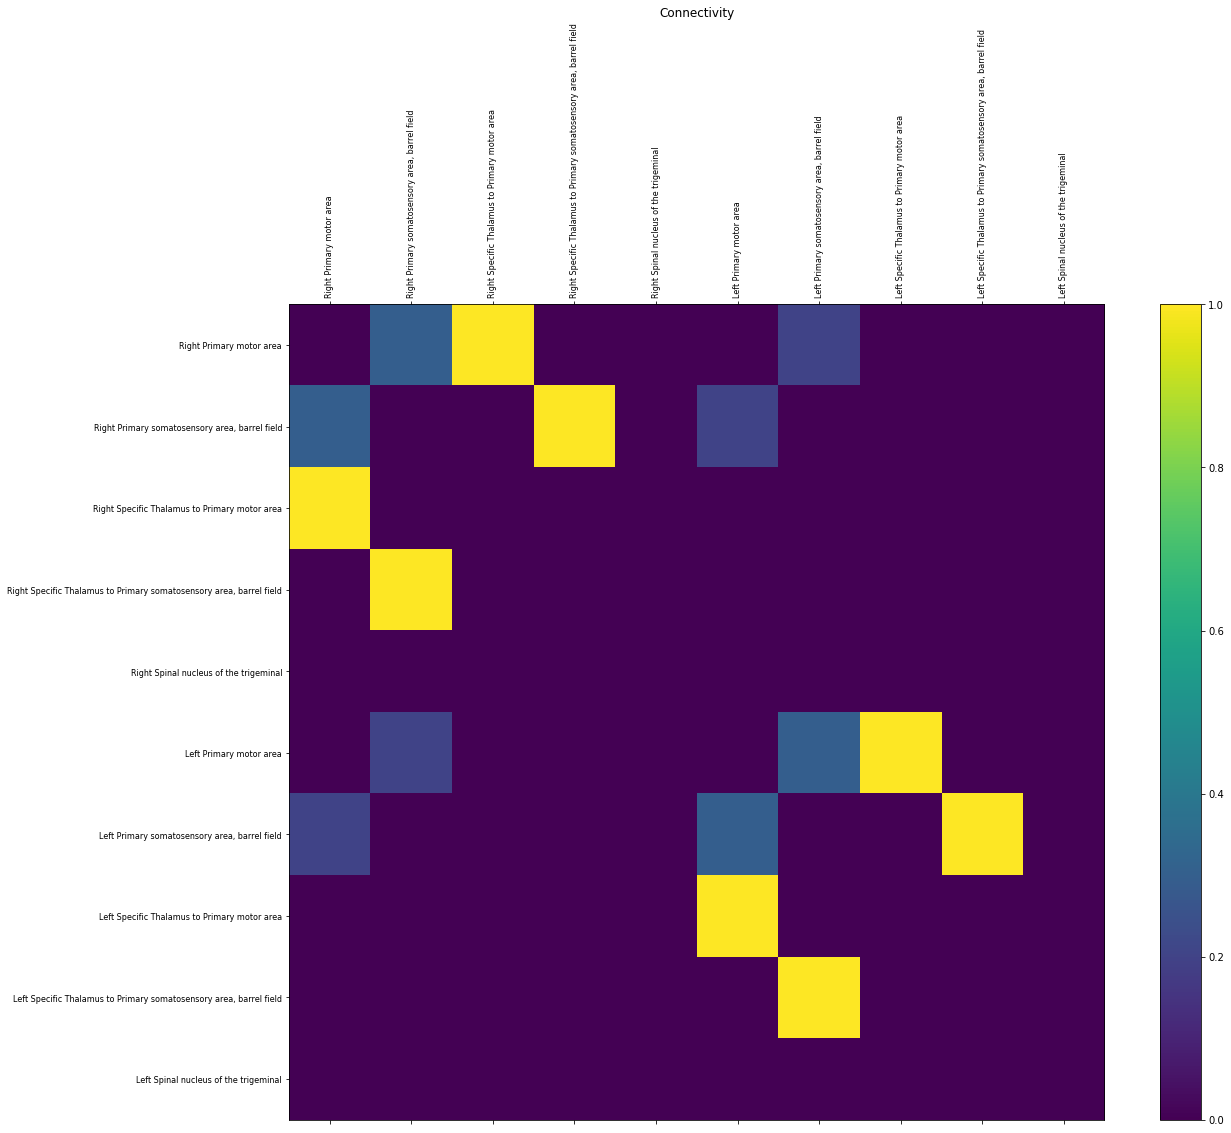

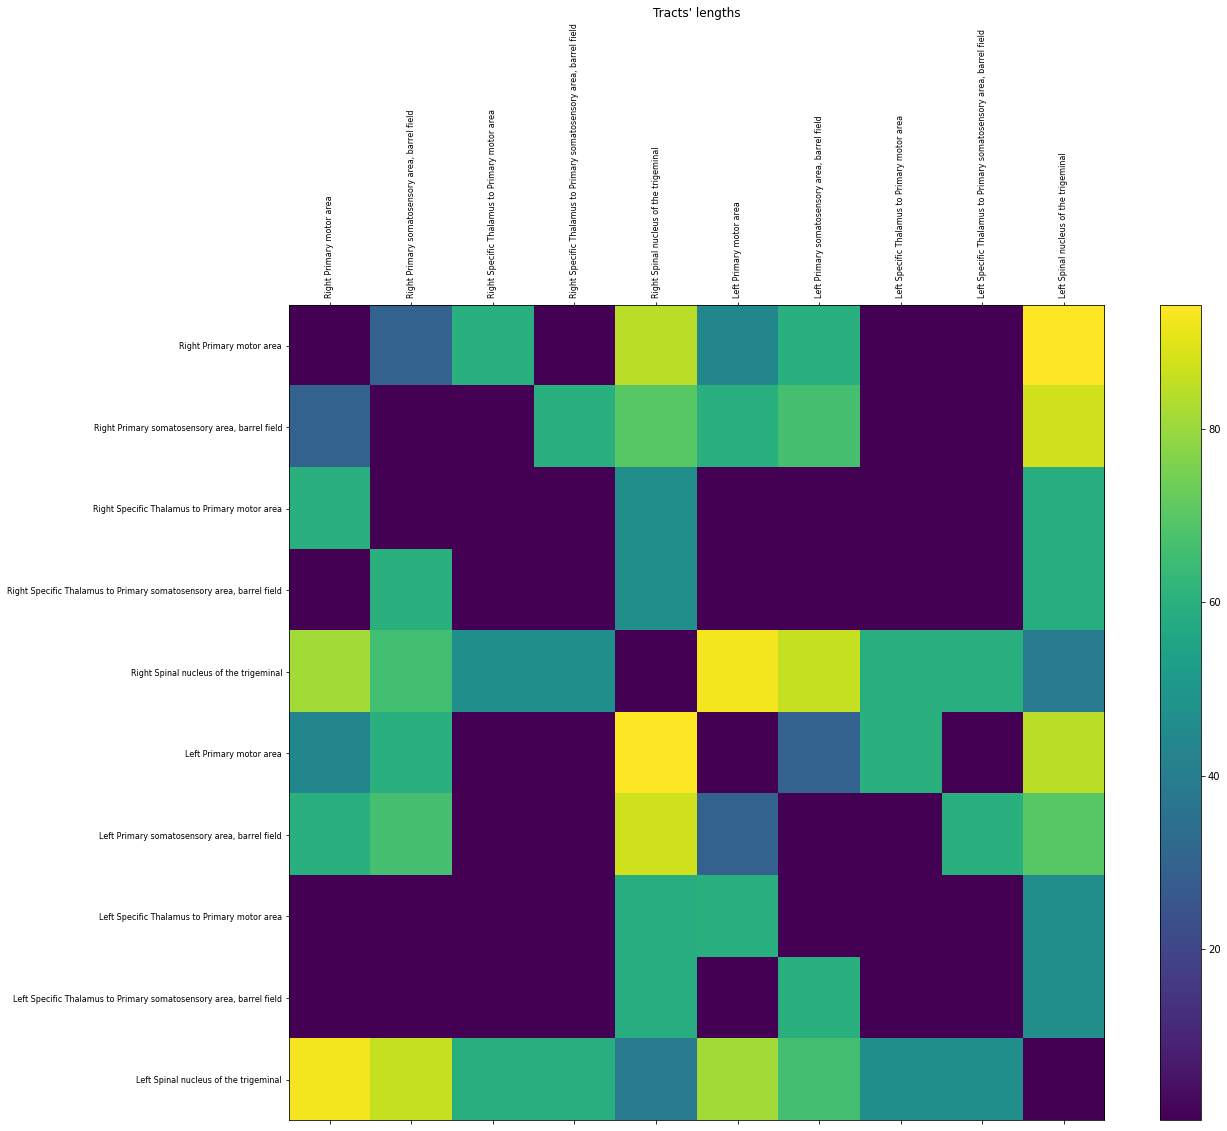

(<Figure size 1440x1080 with 2 Axes>,
 <AxesSubplot:title={'center':'Connectivity'}>,
 <Figure size 1440x1080 with 2 Axes>,
 <AxesSubplot:title={'center':"Tracts' lengths"}>)

In [7]:
FORCE_DELAYS = True


def force_delays(delays, conn=connectivity):
    return delays * conn.speed 
    
    
# Force connectivity:
connectivity.weights *= 0.0

# M1 <-> S1 ipsilateral:
connectivity.weights[newinds["m1"], newinds["s1brl"]] = 0.3
connectivity.weights[newinds["s1brl"], newinds["m1"]] = 0.3

# M1 <-> S1 contralateral:
connectivity.weights[newinds["m1"], newinds["s1brl"][::-1]] = 0.2
connectivity.weights[newinds["s1brl"], newinds["m1"][::-1]] = 0.2

# SpecThal -> Crtx Ipsilateral only:
connectivity.weights[newinds["m1"], newinds["m1thal"]] = 1.0
connectivity.weights[newinds["s1brl"], newinds["s1brlthal"]] = 1.0

# Crtx -> SpecThal Ipsilateral only:
connectivity.weights[newinds["m1thal"], newinds["m1"]] = 1.0
connectivity.weights[newinds["s1brlthal"], newinds["s1brl"]] = 1.0

if TRIGEMINAL:
    # Trigeminal -> SpecThal contralateral only:
    connectivity.weights[newinds["s1brlthal"], newinds["trigeminal"][::-1]] = 1.0
    if M1STIM:
        connectivity.weights[newinds["m1thal"], newinds["trigeminal"][::-1]] = 1.0
    
    
if FORCE_DELAYS:
    # M1 <-> S1 ipsilateral:
    connectivity.tract_lengths[newinds["m1"], newinds["s1brl"]] = force_delays(10.0)
    connectivity.tract_lengths[newinds["s1brl"], newinds["m1"]] = force_delays(10.0)

    # M1 <-> S1 contralateral:
    connectivity.tract_lengths[newinds["m1"], newinds["s1brl"][::-1]] = force_delays(20.0)
    connectivity.tract_lengths[newinds["s1brl"], newinds["m1"][::-1]] = force_delays(20.0)

    # SpecThal -> Crtx Ipsilateral only:
    connectivity.tract_lengths[newinds["m1"], newinds["m1thal"]] = force_delays(20.0)
    connectivity.tract_lengths[newinds["s1brl"], newinds["s1brlthal"]] = force_delays(20.0)

    # Crtx -> SpecThal Ipsilateral only:
    connectivity.tract_lengths[newinds["m1thal"], newinds["m1"]] = force_delays(20.0)
    connectivity.tract_lengths[newinds["s1brlthal"], newinds["s1brl"]] = force_delays(20.0)

    if TRIGEMINAL:
        # Trigeminal -> SpecThal contralateral only:
        connectivity.tract_lengths[newinds["s1brlthal"], newinds["trigeminal"][::-1]] = force_delays(10.0)
        if M1STIM:
            connectivity.tract_lengths[newinds["m1thal"], newinds["trigeminal"][::-1]] = force_delays(10.0)


plotter.plot_tvb_connectivity(connectivity)

In [8]:
from tvb_multiscale.core.tvb.cosimulator.models.wc_thalamocortical_cereb import WilsonCowanThalamoCortical

dummy = np.ones((connectivity.number_of_regions,))

model_params = {}
model_params.update(config.model_params)
STIMULUS = model_params.pop("STIMULUS")

model_params = {}
for p, pval in config.model_params.items():
    if p != "STIMULUS":
        if pval is not None:
            pval = np.array([pval]).flatten()
            if p == 'G':
                # G normalized by the number of regions as in Griffiths et al paper
                # Geff = G /(number_of_regions - inds['thalspec'].size)
                pval = pval / (connectivity.number_of_regions - newinds['thalspec'].size)
            model_params[p] = pval


# Stimuli:
A_st = 0 * dummy.astype("f")
B_st = 0 * dummy.astype("f")
f_st = 0 * dummy.astype("f")
if TRIGEMINAL:
    # Stimulus to trigeminal:
    A_st[newinds["trigeminal"]] = STIMULUS
    B_st[newinds["trigeminal"]] = config.STIMULUS_BASELINE
    f_st[newinds["trigeminal"]] = config.STIMULUS_RATE  # Hz
else:
    A_st[newinds["s1brlthal"]] = STIMULUS
    B_st[newinds["s1brlthal"]] = config.STIMULUS_BASELINE
    f_st[newinds["s1brlthal"]] = config.STIMULUS_RATE  # Hz
    if M1STIM:
        A_st[newinds["m1thal"]] = STIMULUS
        B_st[newinds["m1thal"]] = config.STIMULUS_BASELINE
        f_st[newinds["m1thal"]] = config.STIMULUS_RATE  # Hz
model_params.update({"A_st": A_st, "B_st": B_st, "f_st": f_st})

model = WilsonCowanThalamoCortical(is_cortical=newmaps['is_cortical'][:, np.newaxis],
                                   is_thalamic=newmaps['is_thalamic'][:, np.newaxis],
                                   **model_params)

model.dt = config.DEFAULT_DT

# Remove Specific thalamic relay -> nonspecific subcortical structures connections!
w_se = model.w_se * dummy
w_se[newinds['subcrtx']] = 0.0  #  model.G[0]
model.w_se = w_se
# Remove specific thalamic relay -> inhibitory nonspecific subcortical structures connections
w_si = model.w_si * dummy
w_si[newinds['subcrtx']] = 0.0  # * model.G[0]
model.w_si = w_si

# Long range connections to specific thalamic relay and reticular structures connections' weights:
model.G = model.G * dummy
model.G[newinds["thalspec"]] = 0.0
# Retain connections
# from spinal nucleus of the trigeminal to S1 barrel field specific thalamus:
model.G[newinds["s1brlthal"]] = model.G[newinds["crtx"][0]]
# from Cerebellar Nuclei to M1:
model.G[newinds["m1thal"]] = model.G[newinds["crtx"][0]]

model.configure()

Fixing thalamocortical delays!
2023-12-08 17:15:35,469 - WARNING - tvb_multiscale.core.tvb.cosimulator.cosimulator_serial - There are no existing connections (i.e., with nonzero weights)!
Setting minimum delay to 1 integrator time step = 0.1!.
2023-12-08 17:15:35,469 - WARNING - tvb_multiscale.core.tvb.cosimulator.cosimulator_serial - Current step is not 0 upon configuration!
Setting it to 0. Initial condition might be affected!
Current step is not 0 upon configuration!
Setting it to 0. Initial condition might be affected!
CoSimulatorSerial (
  title ............................... 'CoSimulatorSerial gid: c2a97357-1a5a-4ef3-9988-57ce0d6c51ee'
  Type ................................ 'CoSimulatorSerial'
  model ............................... WilsonCowanThalamoCortical gid: 82c5ae98-1a5d-422f-9f01-459816c9d1f9
  output_interfaces ................... None
  input_interfaces .................... None
  out_proxy_inds ...................... --------------------
  shape .....................

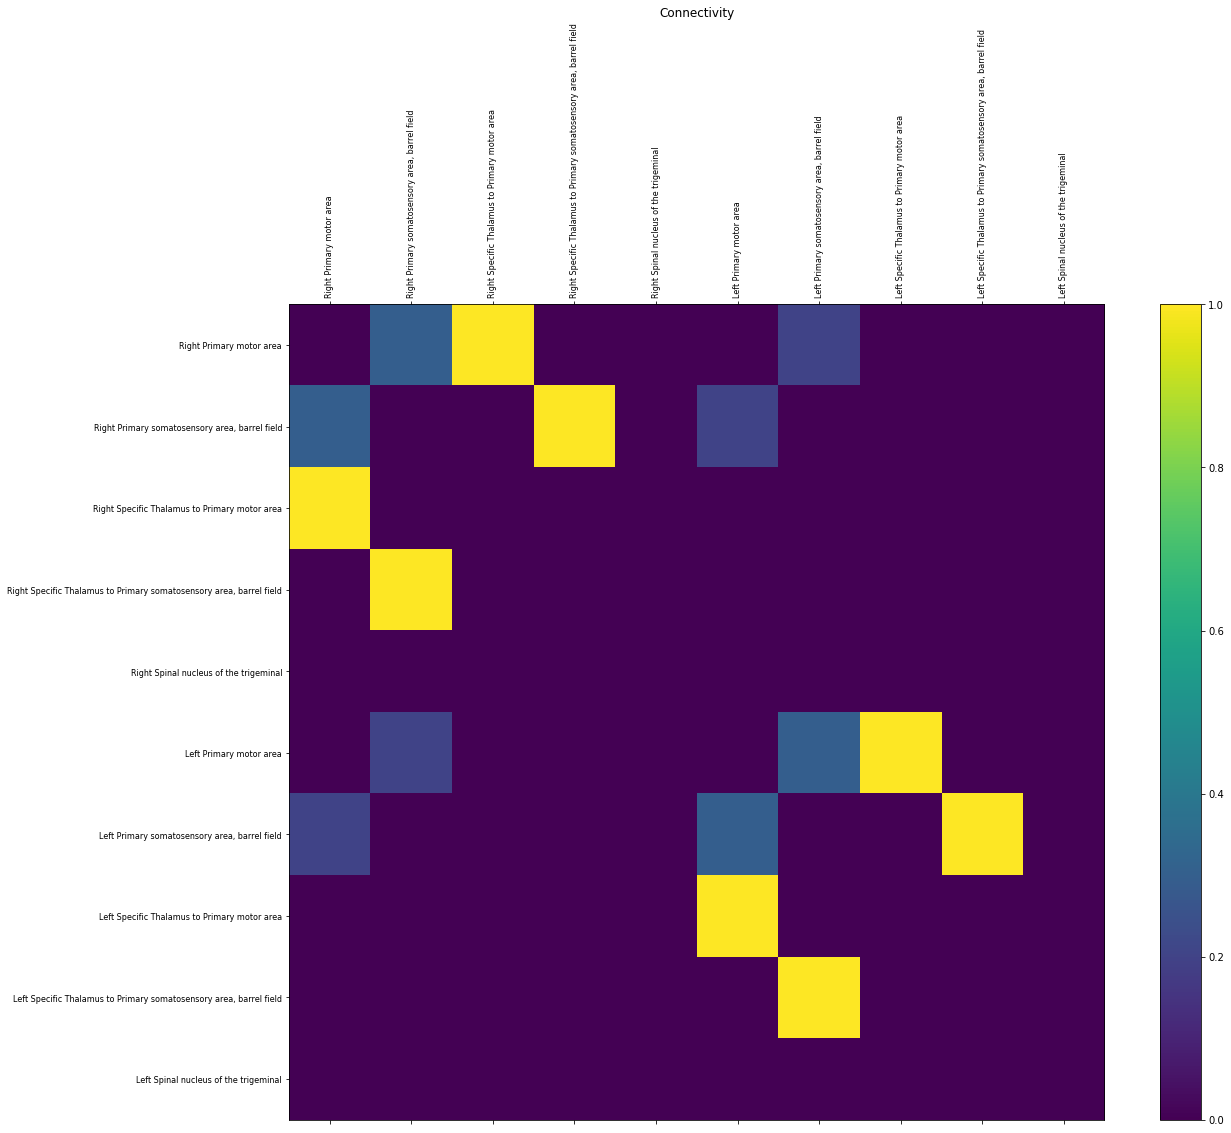

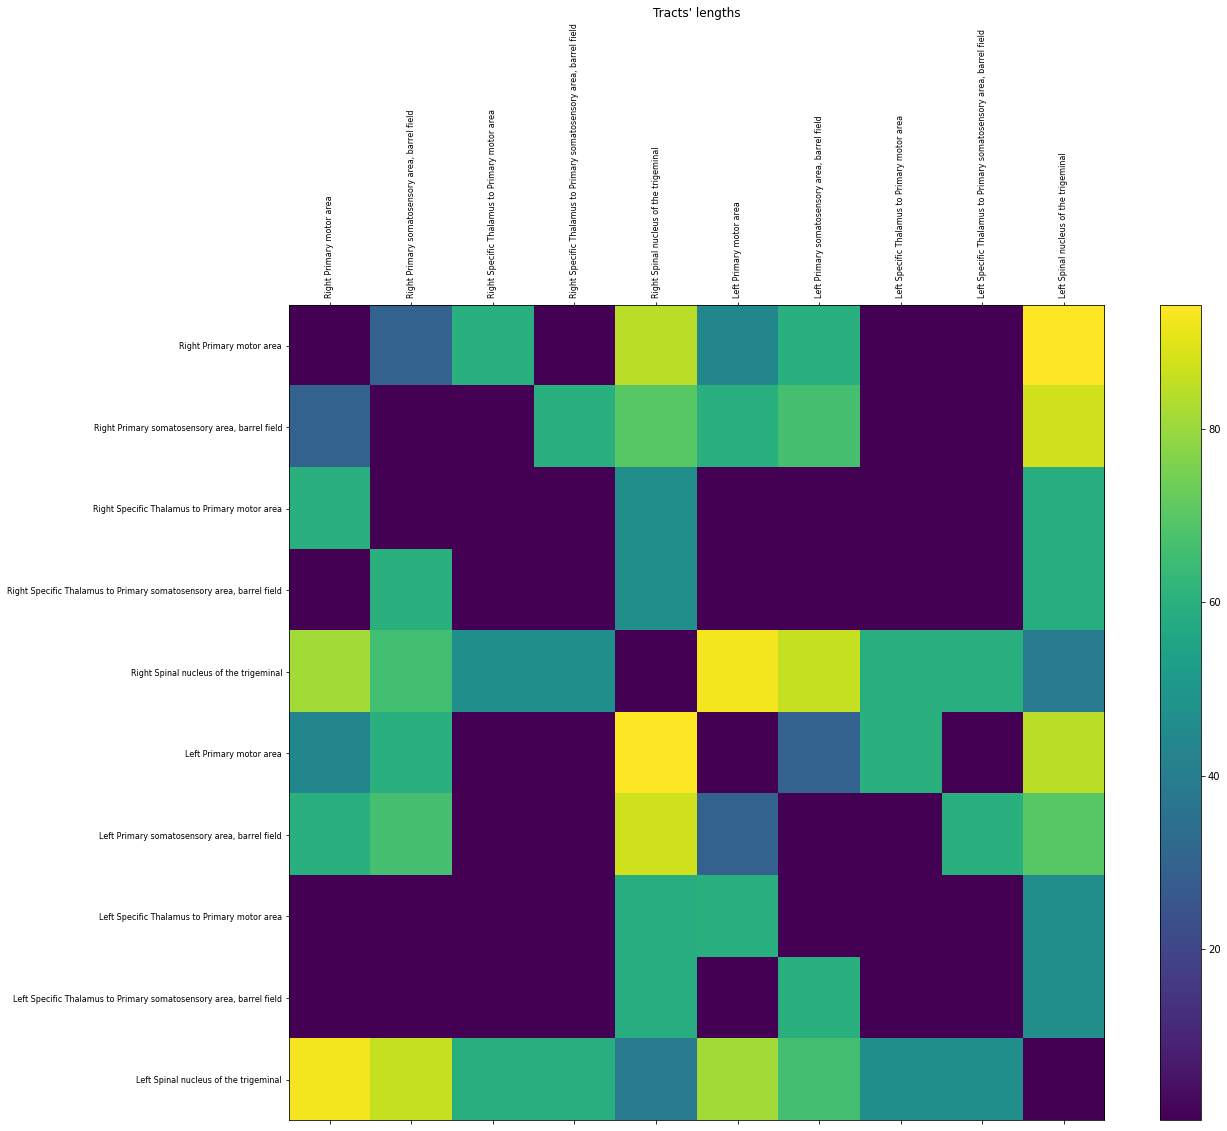

In [9]:
simulator = build_simulator(connectivity, model, newinds, newmaps, config, plotter)
simulator.integrator.noise.nsig = np.array([1e-4])

In [10]:
def print_weight_to_indegree(src, trg, inds, w, hemispheres=1):
    print("\n" + "-"*25)
    print("%s -> %s" % (src, trg))
    print(w[inds[trg]][:, inds[src]])
    print("%:")
    print(w[inds[trg]][:, inds[src]] / w[inds[trg]].sum() * 200 / (2 - np.abs(hemispheres)))
    
print("\n" + "-" * 50)
print("Pathway connections to indegree:")

for conns in [
    ["s1brl", "m1"], ["m1", "s1brl"]]:
    print_weight_to_indegree(conns[0], conns[1], newinds, connectivity.weights, hemispheres=0)

for conns in [
    ["s1brlthal", "s1brl"],
    ["s1brl", "s1brlthal"], ["trigeminal", "s1brlthal"],
    ["m1thal", "m1"],
    ["m1", "m1thal"], ["trigeminal", "m1thal"], 

]:
    print_weight_to_indegree(conns[0], conns[1], newinds, simulator.connectivity.weights, 
                             hemispheres=hemispheres)


--------------------------------------------------
Pathway connections to indegree:

-------------------------
s1brl -> m1
[[0.3 0.2]
 [0.2 0.3]]
%:
[[10.          6.66666667]
 [ 6.66666667 10.        ]]

-------------------------
m1 -> s1brl
[[0.3 0.2]
 [0.2 0.3]]
%:
[[10.          6.66666667]
 [ 6.66666667 10.        ]]

-------------------------
s1brlthal -> s1brl
[[1. 0.]
 [0. 1.]]
%:
[[66.66666667  0.        ]
 [ 0.         66.66666667]]

-------------------------
s1brl -> s1brlthal
[[1. 0.]
 [0. 1.]]
%:
[[100.   0.]
 [  0. 100.]]

-------------------------
trigeminal -> s1brlthal
[[0. 0.]
 [0. 0.]]
%:
[[0. 0.]
 [0. 0.]]

-------------------------
m1thal -> m1
[[1. 0.]
 [0. 1.]]
%:
[[66.66666667  0.        ]
 [ 0.         66.66666667]]

-------------------------
m1 -> m1thal
[[1. 0.]
 [0. 1.]]
%:
[[100.   0.]
 [  0. 100.]]

-------------------------
trigeminal -> m1thal
[[0. 0.]
 [0. 0.]]
%:
[[0. 0.]
 [0. 0.]]


In [11]:
# from cosim_run_plot import apply_pathway_gain_increase

In [12]:
# w1 = apply_pathway_gain_increase(inds["trigeminal"], inds["ansilob"], 50, w.copy())

In [13]:
results, transient = simulate(simulator, config)


Simulated in 41.029420 secs!


2023-12-08 17:16:17,585 - INFO - tvb.storage.h5.encryption.data_encryption_handler - Cannot import syncrypto library.
Pickle-dumping source_ts to /home/docker/packages/tvb-multiscale/rising_net/working_files/s1stim_stimbase10_stim5_nsd0/res/source_ts.pkl!
Raw ts:
TimeSeriesRegion (
  Dimensions .......... ['Time', 'State Variable', 'Region', 'Neurons']
  Length .............. 12500
  Region Mapping ...... None
  Region Mapping Volume  None
  Sample period ....... 1.0
  Source Connectivity . Connectivity gid: 21b77ddd-ef99-449f-9d99-95675688b1a6
  Time units .......... ms
  Time-series name .... Region Time Series
  Time-series type .... TimeSeriesRegion
  [min, median, max] .. [-2.69327, -0.300709, 2.38233]
  dtype ............... float64
  shape ............... (12500, 3, 10, 1)
)
BOLD ts:
TimeSeriesRegion (
  Dimensions .......... ['Time', 'State Variable', 'Region', 'Neurons']
  Length .............. 12
  Region Mapping ...... None
  Region Mapping Volume  None
  Sample period .....

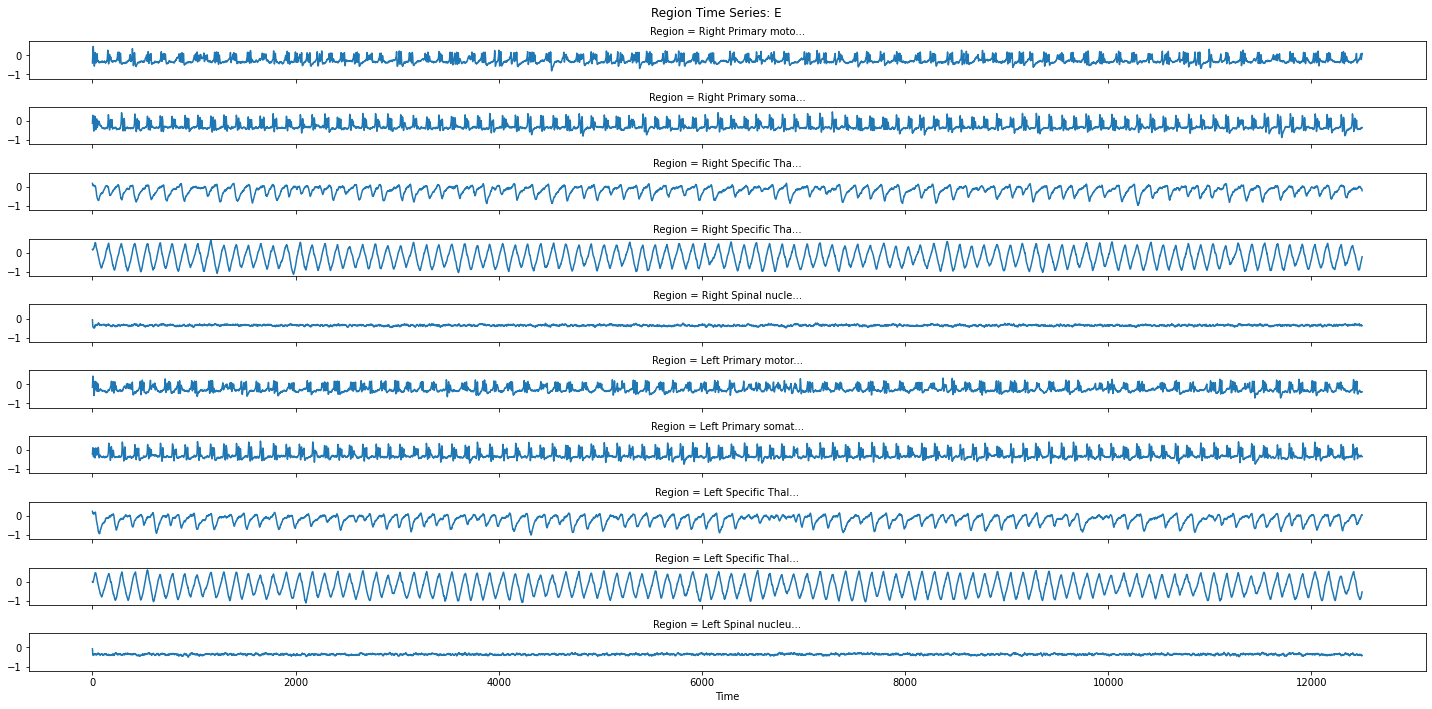

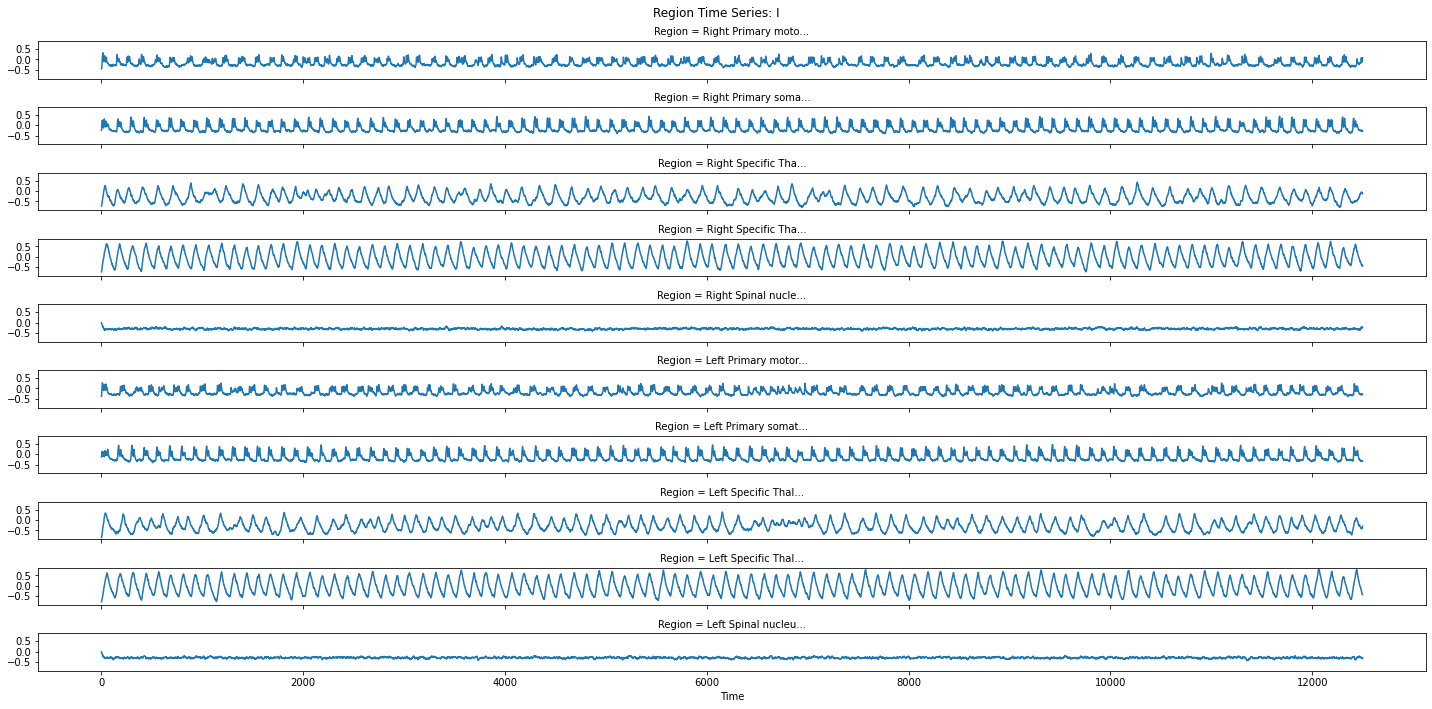

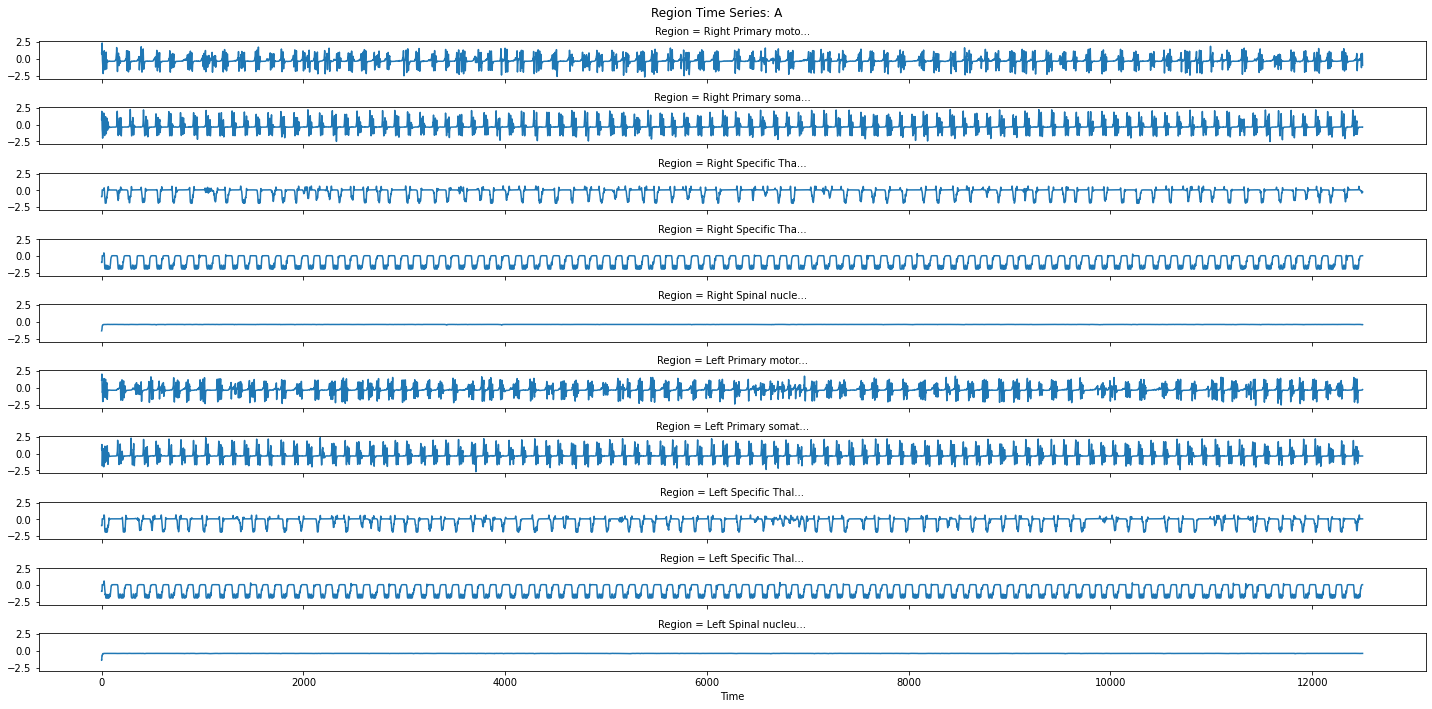

2023-12-08 17:16:20,173 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:20,174 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!
2023-12-08 17:16:20,180 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:20,181 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


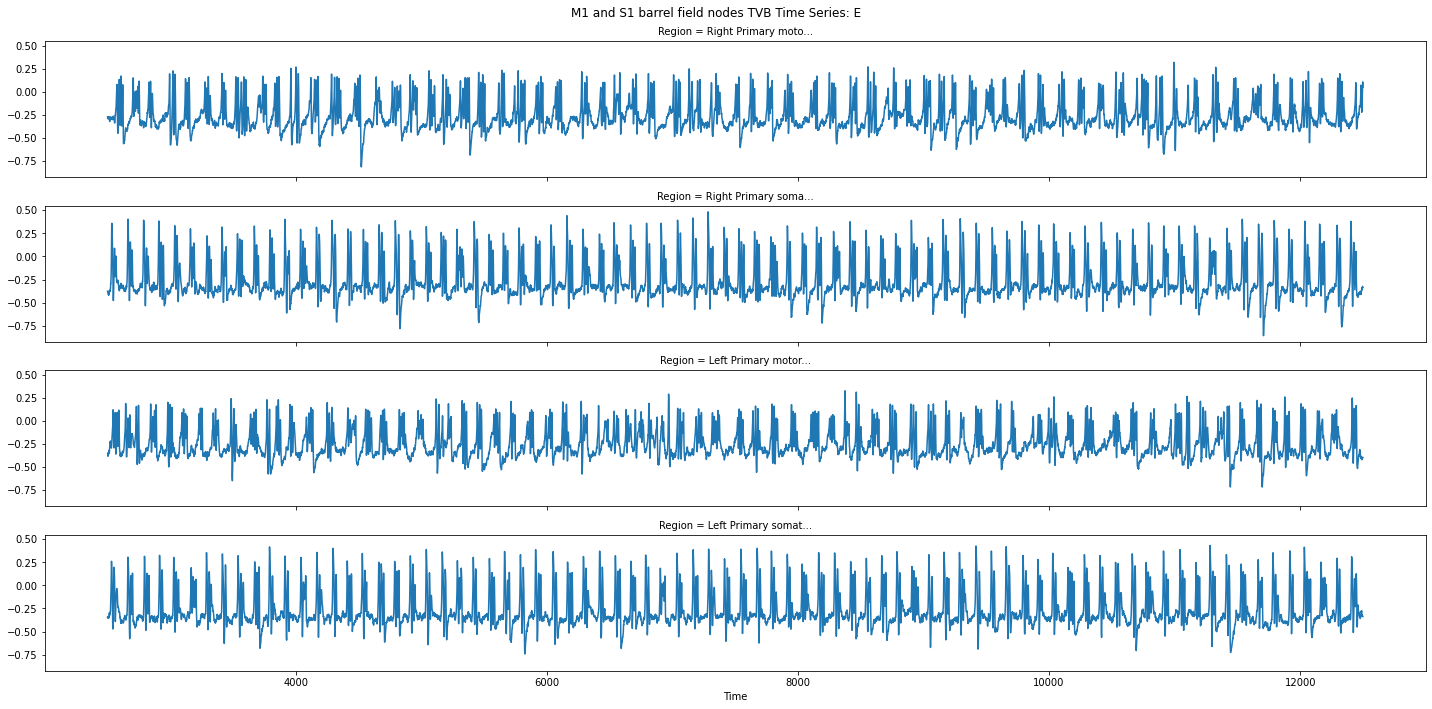

2023-12-08 17:16:20,565 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:20,565 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


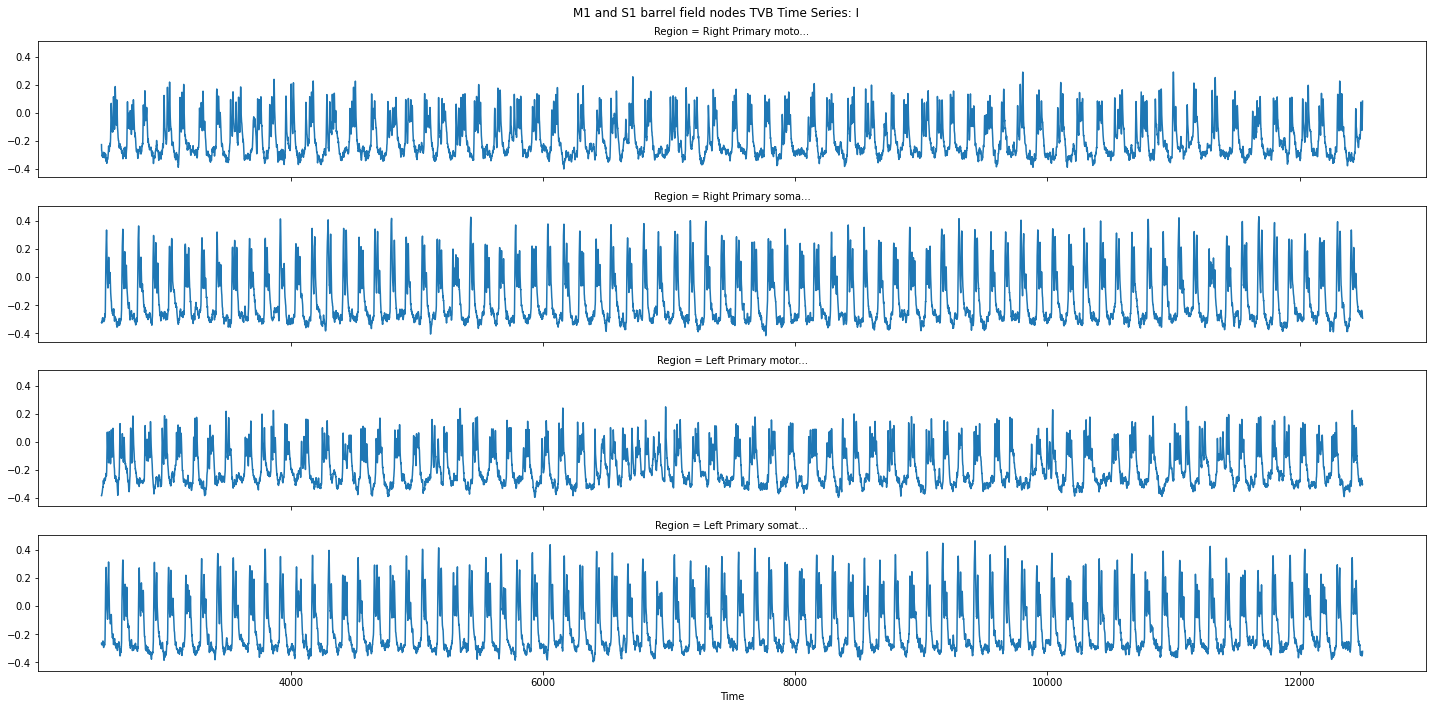

2023-12-08 17:16:20,957 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:20,957 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


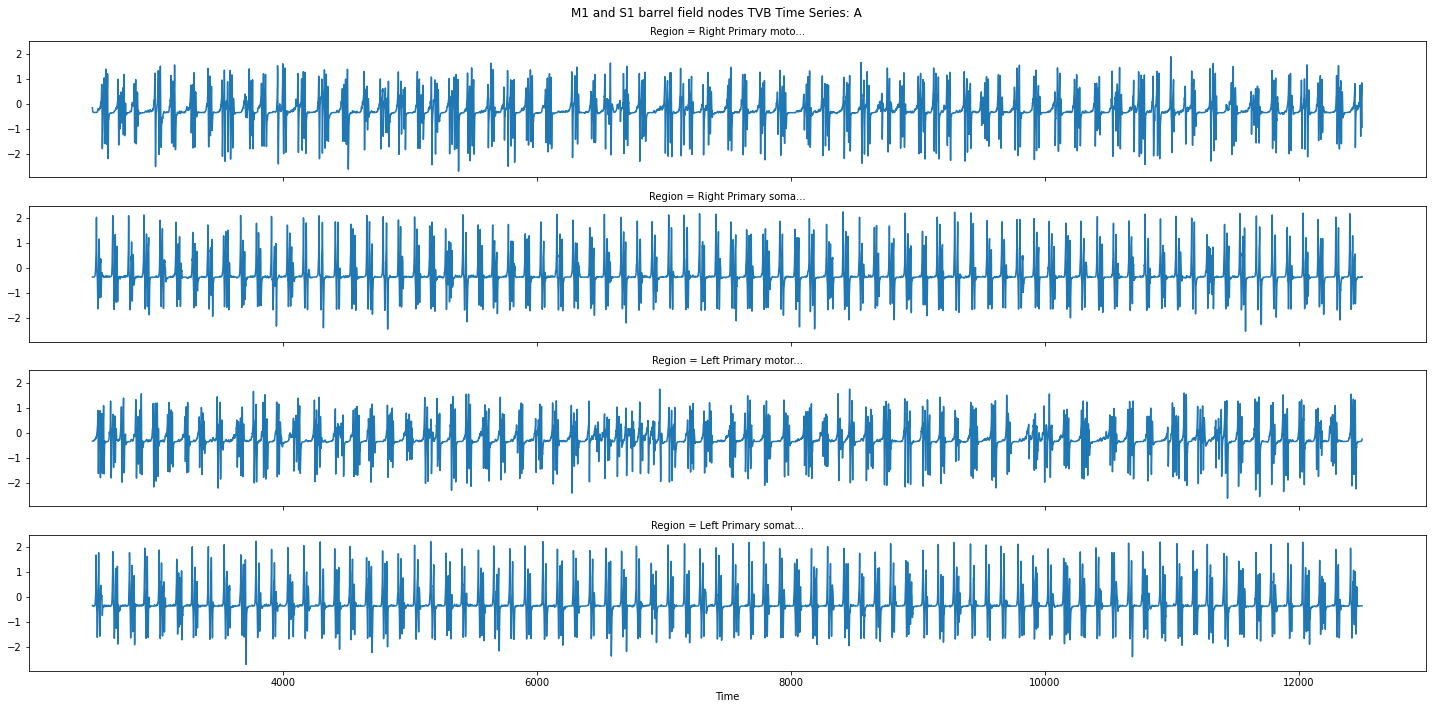

2023-12-08 17:16:21,343 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:21,344 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!
2023-12-08 17:16:21,350 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:21,350 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


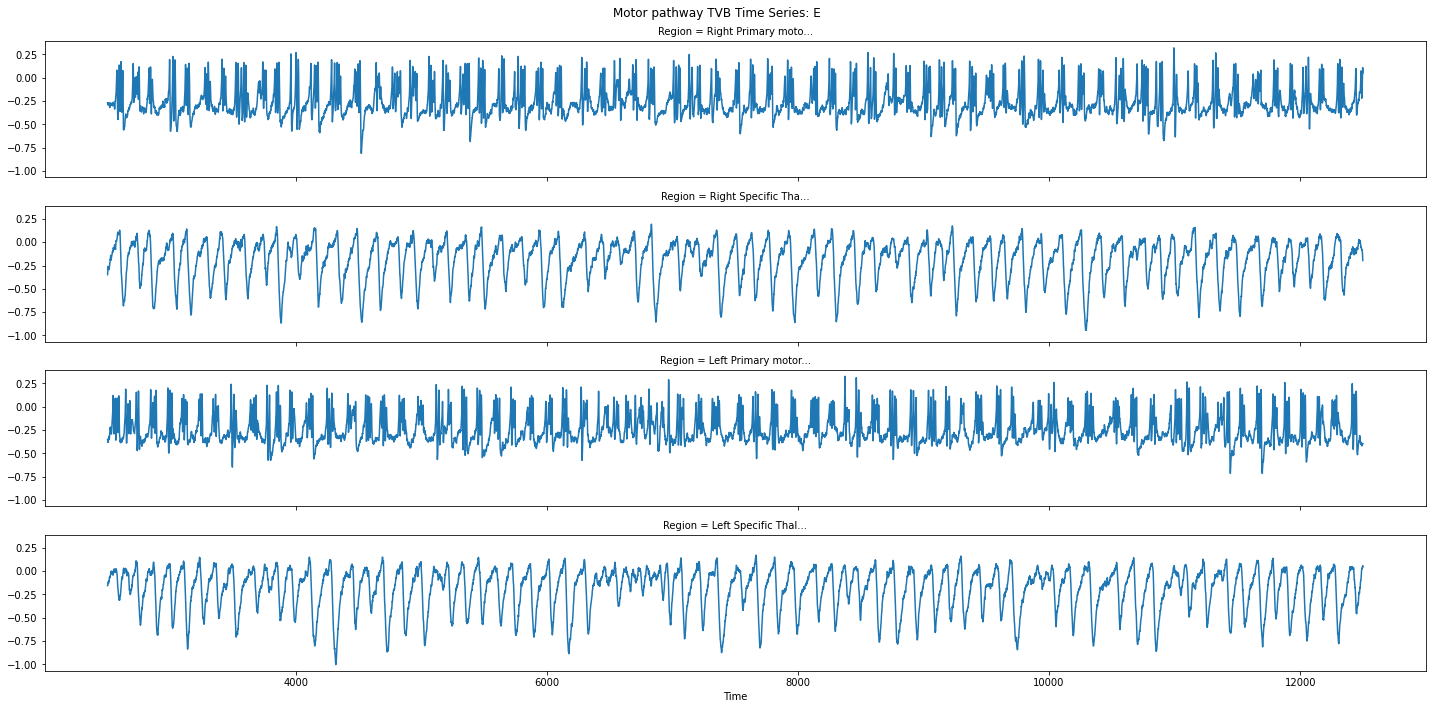

2023-12-08 17:16:21,732 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:21,733 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


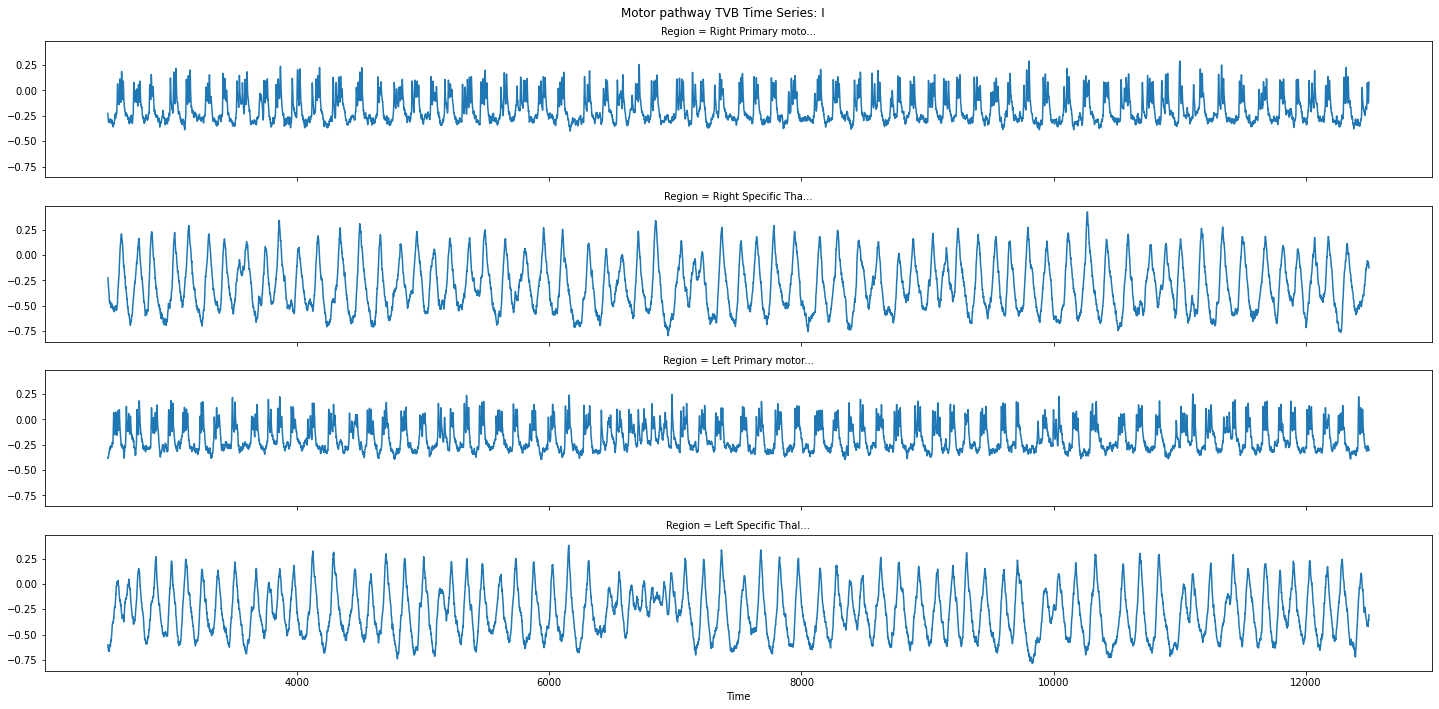

2023-12-08 17:16:22,093 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:22,094 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


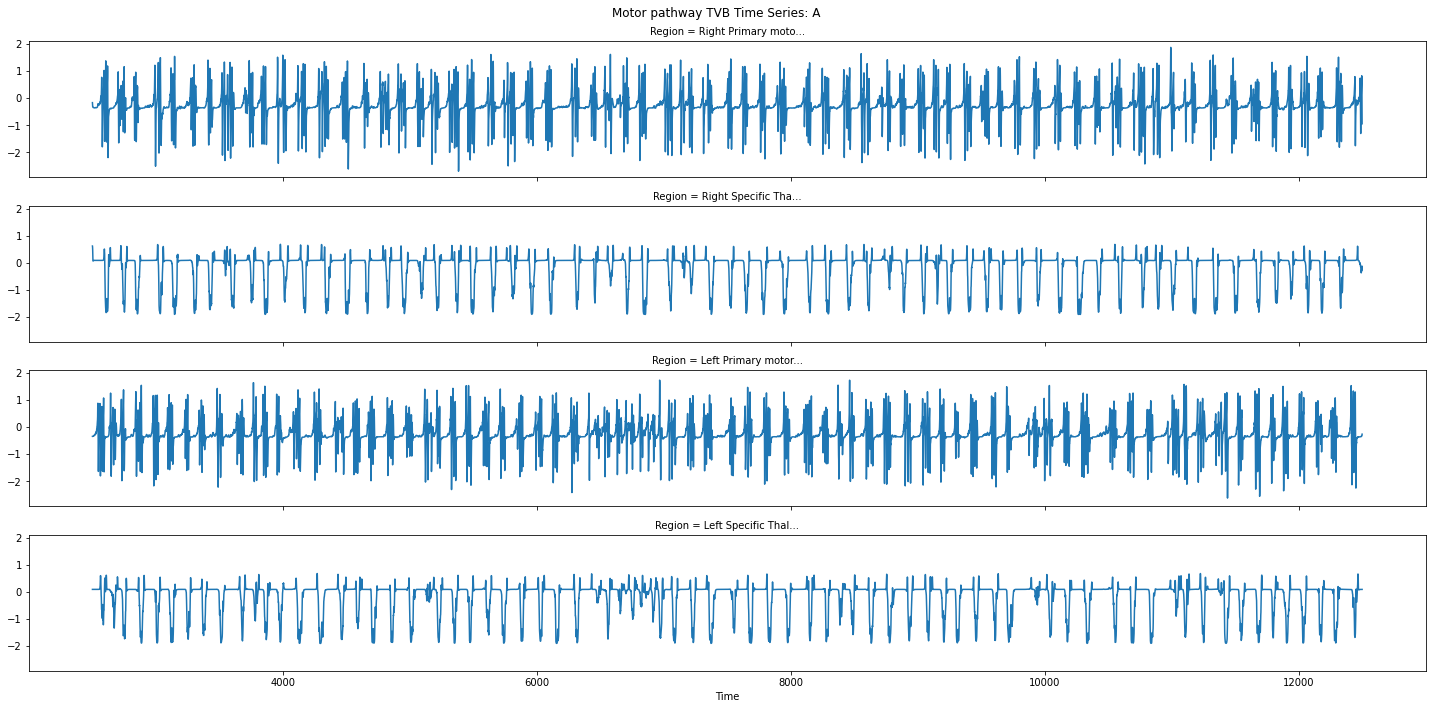

2023-12-08 17:16:22,577 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:22,578 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!
2023-12-08 17:16:22,584 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:22,585 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


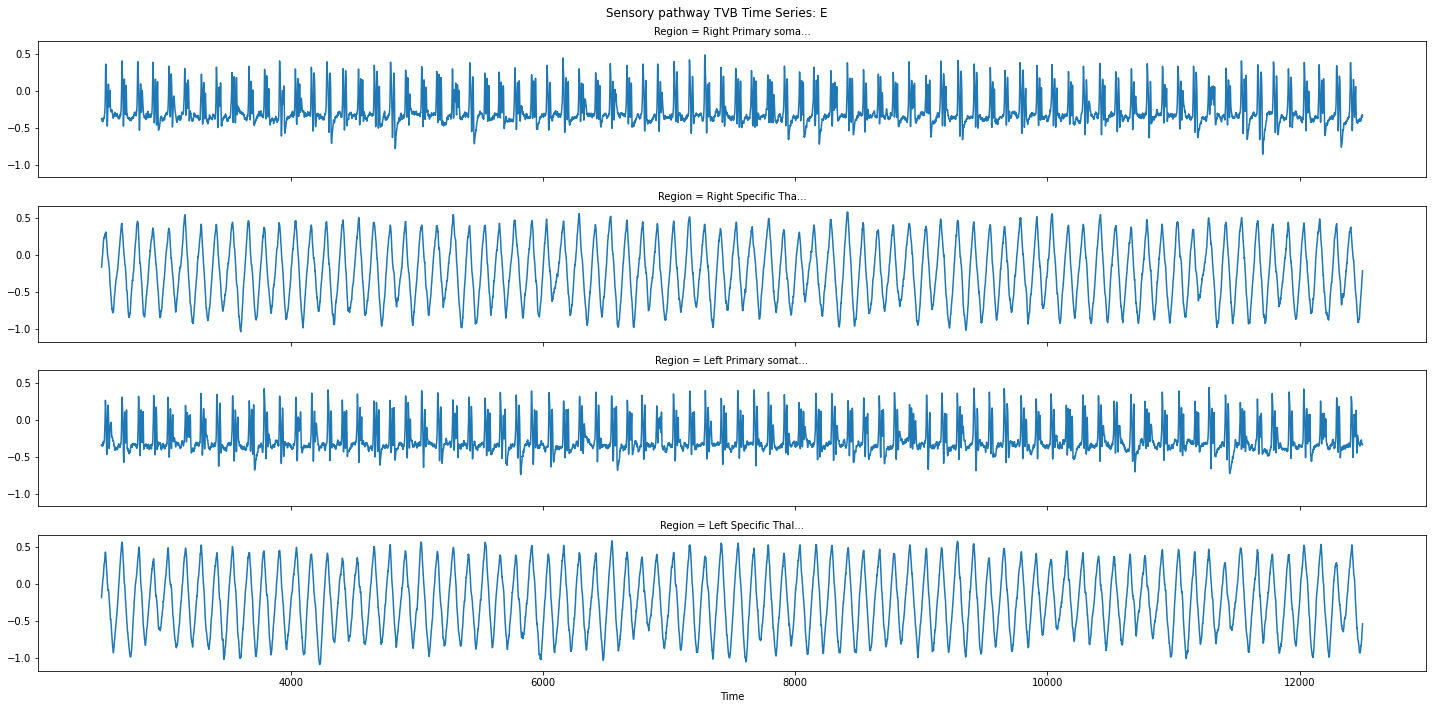

2023-12-08 17:16:22,979 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:22,980 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


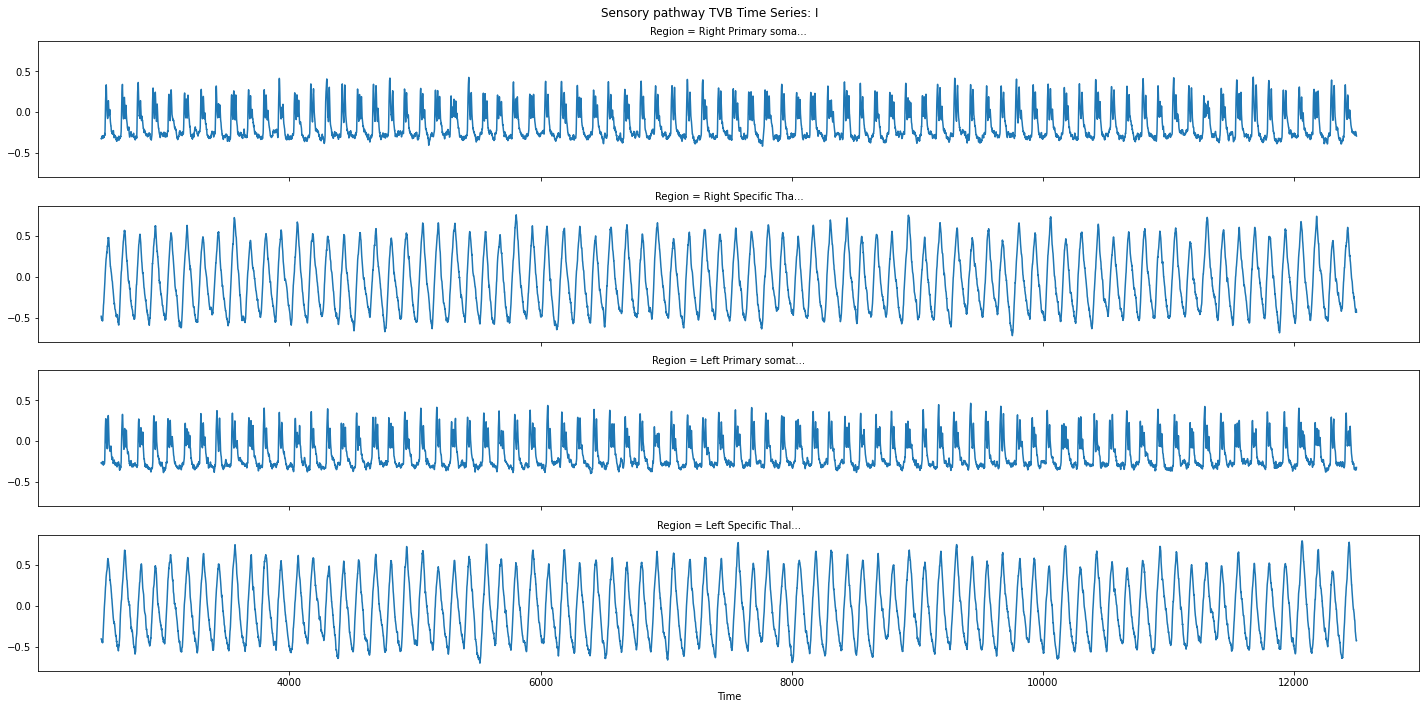

2023-12-08 17:16:23,344 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:23,345 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


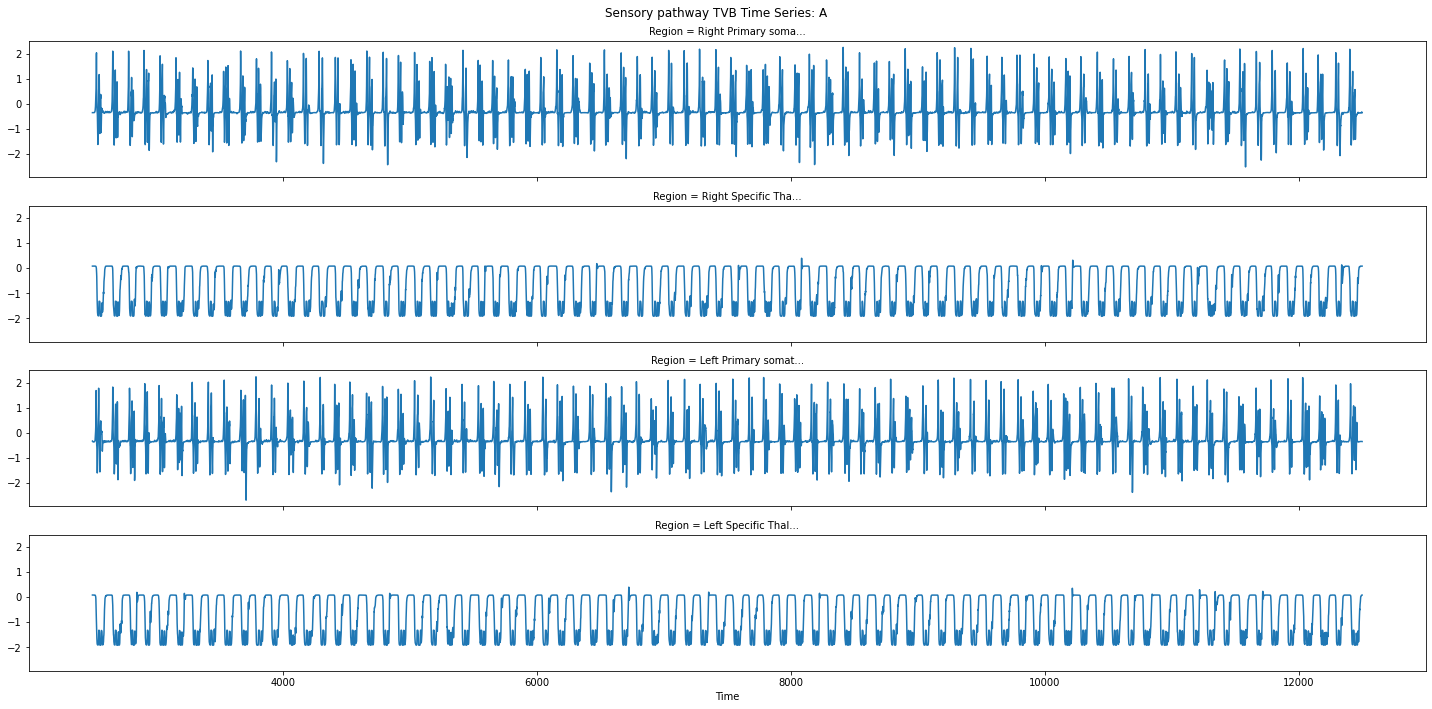

2023-12-08 17:16:23,710 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:23,711 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


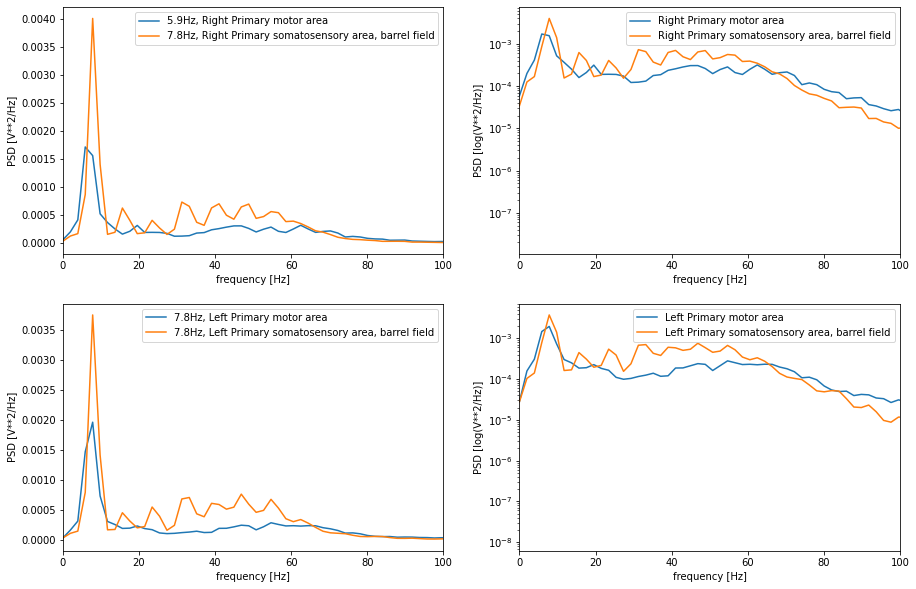

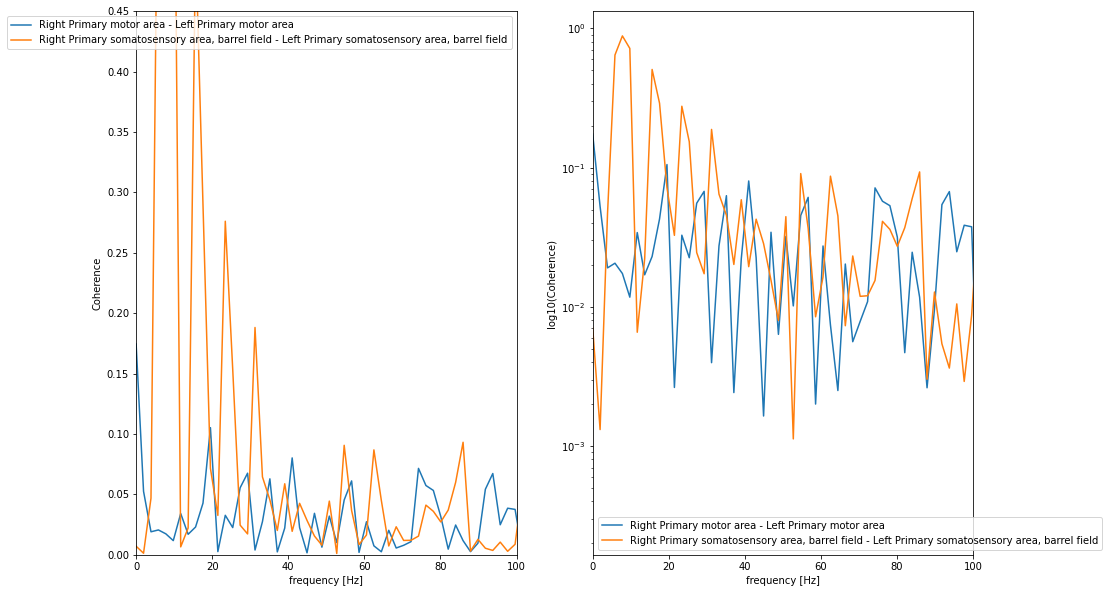

2023-12-08 17:16:24,633 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:24,634 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


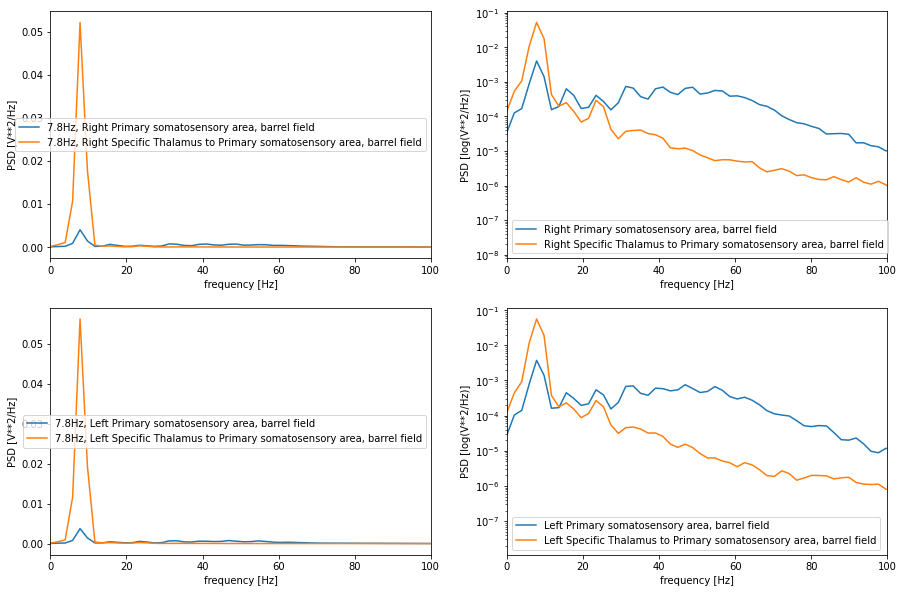

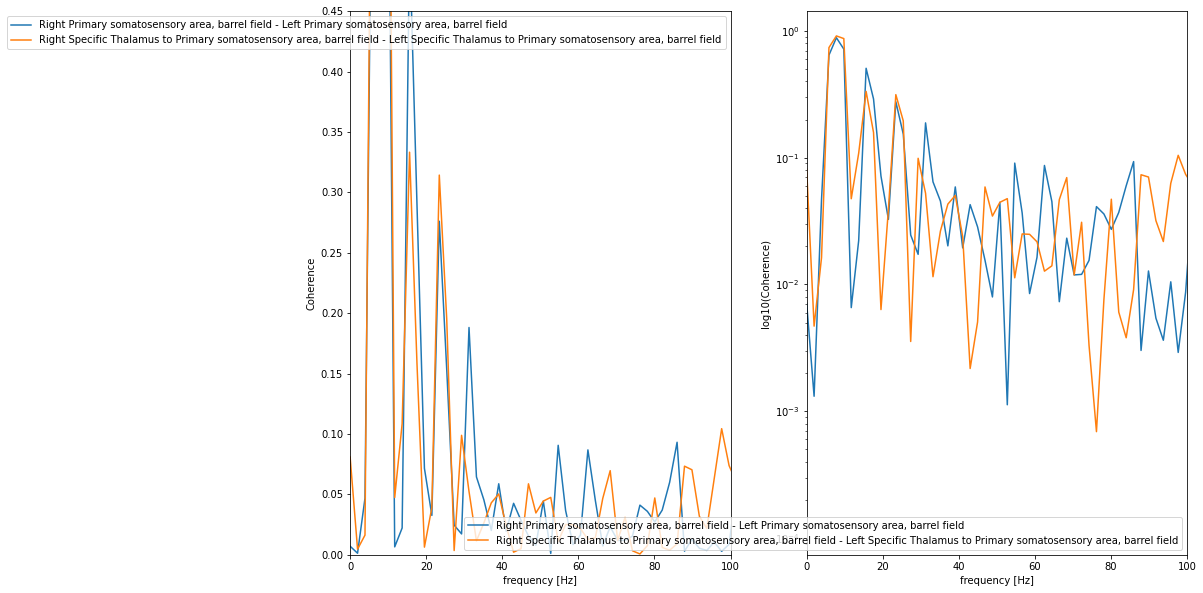

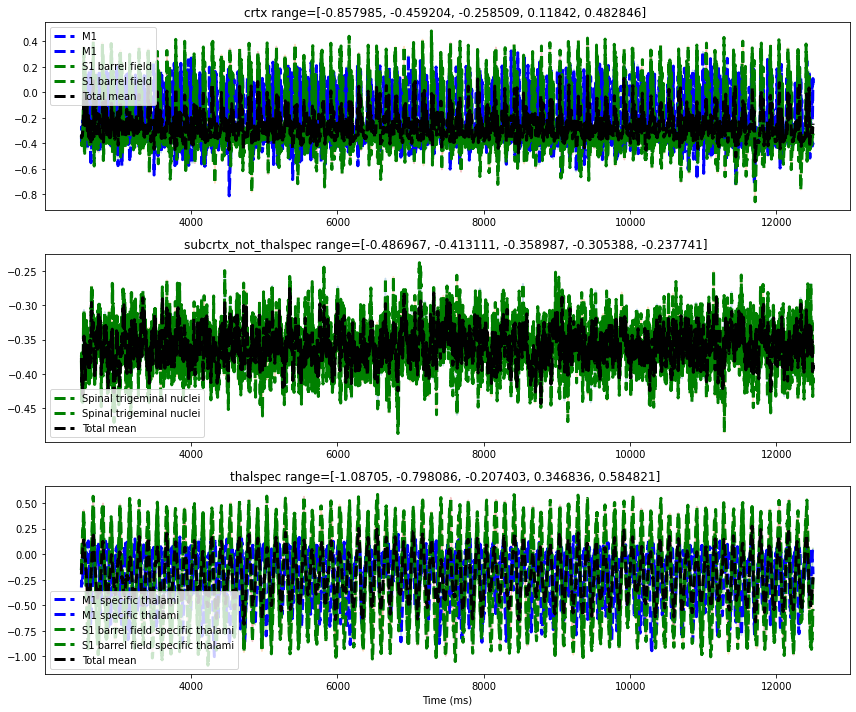

2023-12-08 17:16:27,196 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:27,197 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


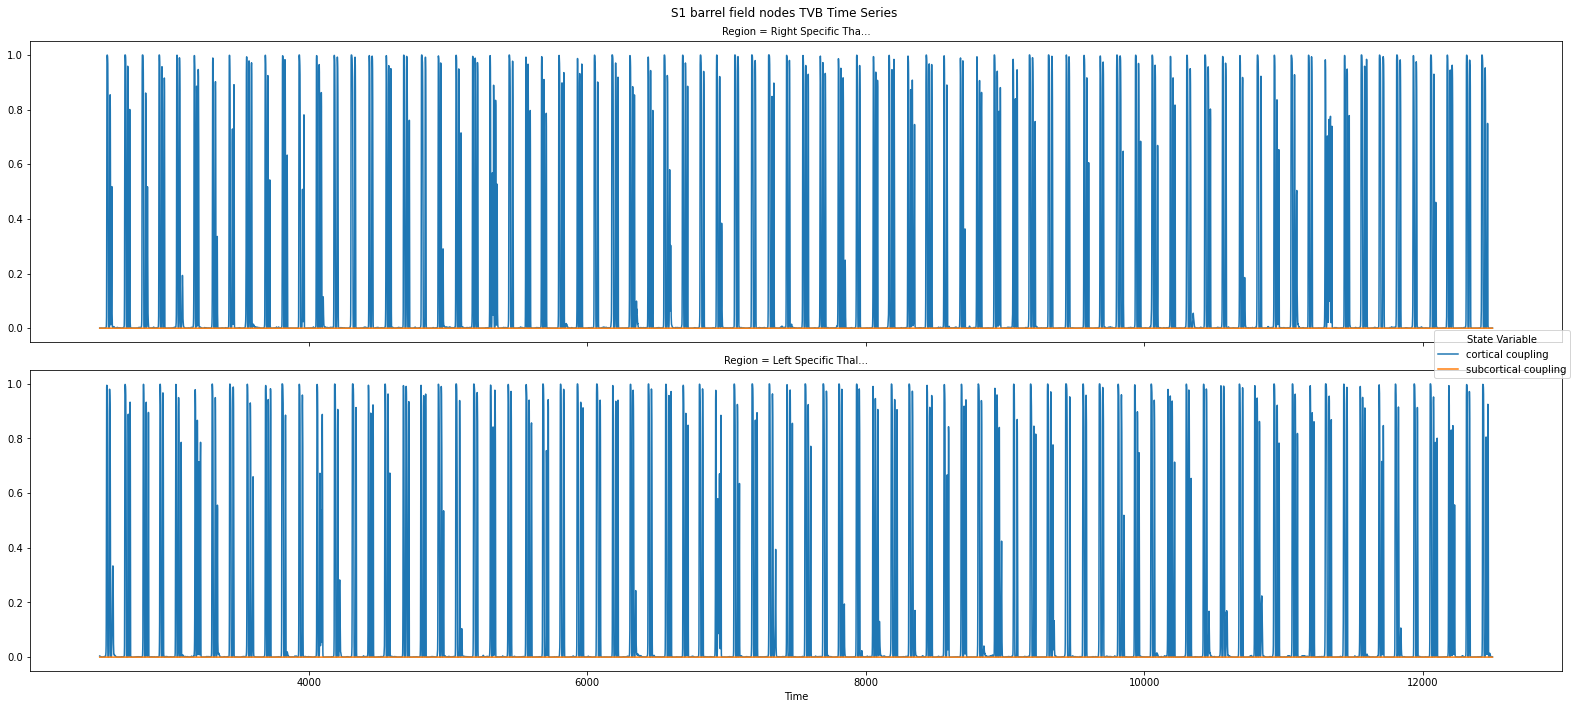

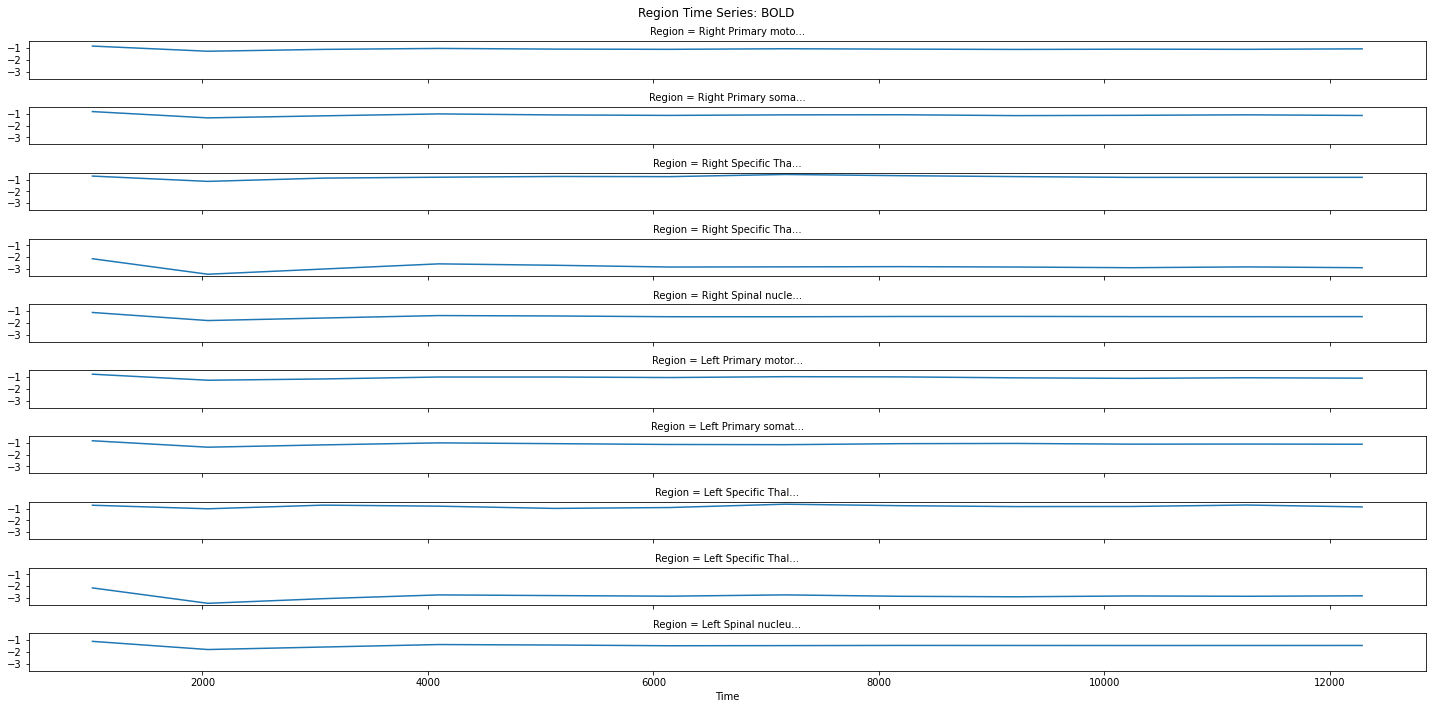

In [14]:
# Compute coherence
transient = config.TRANSIENT_RATIO * config.SIMULATION_LENGTH
if config.RAW_PERIOD > config.DEFAULT_DT:
    transient = (transient // config.RAW_PERIOD) * config.RAW_PERIOD + config.RAW_PERIOD/2

results = plot_tvb(transient, newinds,
                   results=results, simulator=simulator, plotter=plotter, config=config, write_files=True)

2023-12-08 17:16:28,146 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:28,147 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


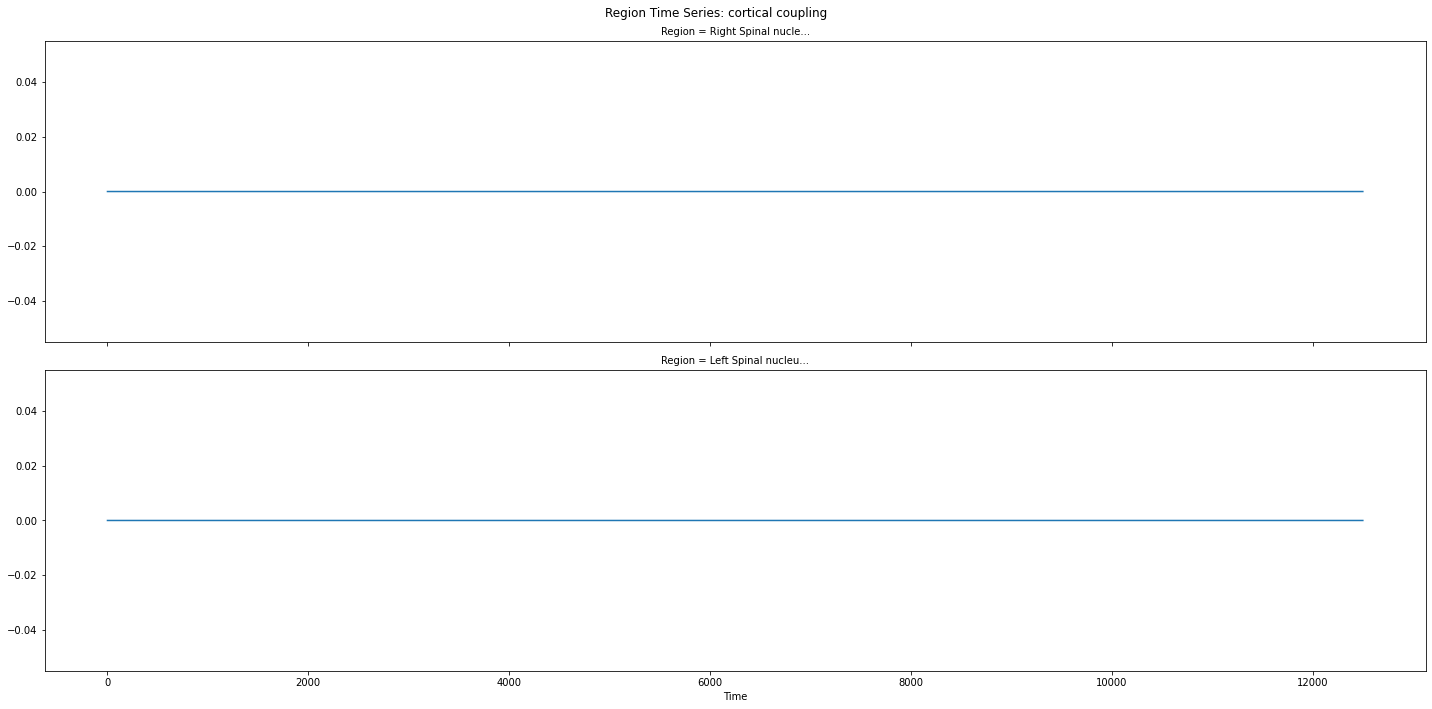

In [15]:
results["afferent_ts"][:, [0], newinds["trigeminal"]].plot_timeseries(plotter_config=plotter.config, 
                                                                      figsize=(20, 10))

2023-12-08 17:16:28,340 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-12-08 17:16:28,340 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


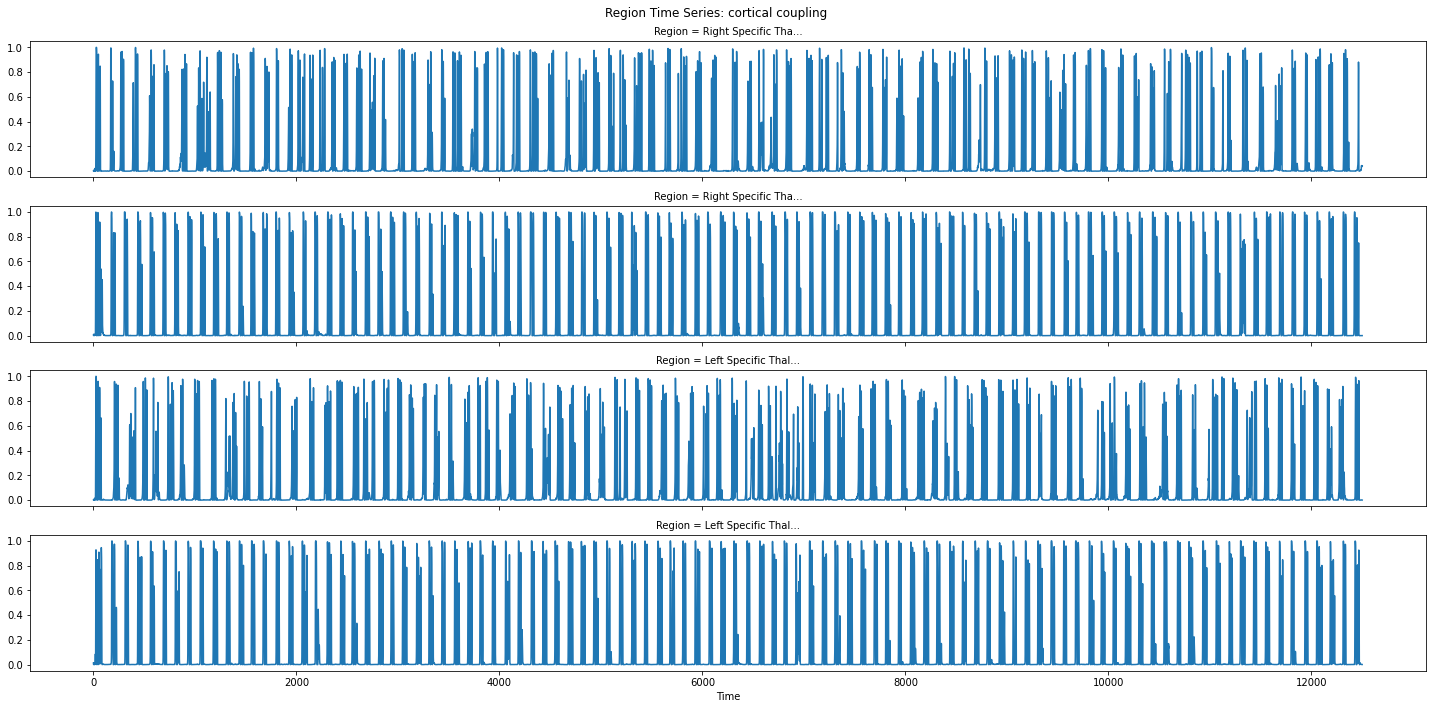

In [16]:
results["afferent_ts"][:, [0], newinds["thalspec"]].plot_timeseries(plotter_config=plotter.config, 
                                                                    figsize=(20, 10))

In [17]:
simulator.integrator.noise.nsig

array([0.0001])

In [18]:
config.FIC

0.0

In [19]:
# import pickle
# results_path = os.path.join(config.out.FOLDER_RES, '%s.pickle' % resfilename)
# with open(results_path, 'wb') as handle:
#    pickle.dump(results, handle)
# print(results_path)
# # results = pickle.load(results_path, 'rb'))  # to load results

In [20]:
# cohfilename = "coherence_30sec_%s_noise_seed_%d" % (test_name, seed)
# coherence_path = os.path.join(config.out.FOLDER_RES, '%s.pickle' % cohfilename)
# # Save coherence
# CxyR = results["CxyR_M1_S1"]
# fR = results["fR"]
# CxyL = results["Cxyl_M1_S1"]
# fL = results["fL"]
# with open(coherence_path, 'wb') as handle:
#     pickle.dump([CxyR, fR, fL, CxyL], handle)
# print(coherence_path)

In [21]:
! pwd
# To run a simulation:
# ! python cosim_run_plot.py test_name=cosim seed=0

/home/docker/packages/tvb-multiscale/rising_net/working_files


In [22]:
# from cosim_run_plot import cosim_run_plot
# results = cosim_run_plot(test_name="cerebOFF", seed=0, # STIMULUS=0.4, # pathway_gain=50.0, 
#                          simulation_length=3000.)


In [23]:
import glob
import pickle
import os
from rising_net.utils import *
from rising_net.plot_utils import *


# Results path:
BASEPATH = "/home/docker/packages/tvb-multiscale/rising_net/working_files"
# BASEPATH = BASEPATH + "/outputs/tvb-only_VS_cerebOFF_stim_gain_simlen3000/stimbase0" 

# Task related regions' indices:
# inds["taskcereb"] = np.sort(np.concatenate([newinds['ansilob'], newinds['cereb_nuclei'], newinds['cereb_crtx']]))
TASKINDS = np.sort(np.concatenate([newinds["m1"], newinds["s1brl"], 
                                   newinds["m1thal"], newinds["s1brlthal"], 
                                   newinds["trigeminal"] #, newinds["ponsmotor"], newinds["ponssens"], 
                                   # newinds['taskcereb']
                                  ]))
# Task related regions' labels:
REGION_LABELS = connectivity.region_labels[TASKINDS]
# Task related regions' abreviated labels:
SHORT_LABELS = [shorten_region_name(reg, exclude=["of", "the", "to"]) for reg in REGION_LABELS]

THETA = [3.0, 10.0]  # Hz
GAMMA = [25.0, 45.0]  # Hz

# results dictionary:
results = {"inds": TASKINDS, 
           "region_labels": REGION_LABELS, "short_labels": SHORT_LABELS,
           "theta": THETA, "gamma": GAMMA}

PATHWAY_GAIN = 0.0 # 50.0# 200.0  # 50.0
PATHWAY_MODE = "task" # , "stim"

TESTS = ["s1m1stim", "s1stim"]
for test_name in TESTS: 
    
    results[test_name] = {}
    Ps = []
    Cs = []
    CsTheta = []
    CsGamma = []
    
    resfilename = "%s_stimbase%d_stim%d" % (test_name, int(10*STIMULUS_BASELINE), int(10*STIMULUS))
    if PATHWAY_GAIN > 1.0:
        if PATHWAY_MODE == "stim":
            resfilename += "_stimgain"
        else:
            resfilename += "_gain"
        resfilename += "%d" % int(PATHWAY_GAIN)
    testpath = os.path.join(BASEPATH, resfilename)
    print(testpath)
    for path in glob.glob(testpath + "_nsd*"):
        resultsfile = os.path.join(path, "res/source_ts.pkl")
        with open(resultsfile, 'rb') as handle:
            source_ts = pickle.load(handle)  # to load results
        Pxx_den, Cxy, f, ij = compute_selected_spectra_coherence(
                                    source_ts["time_series"], TASKINDS,
                                    transient=source_ts["time_series"].shape[0]-2**15, # 2**15 final length
                                    sample_period=source_ts["sample_period"], 
                                    nperseg=512, fmin=0.0, fmax=50.0)
        Ps.append(Pxx_den)
        Cs.append(Cxy)

    results[test_name]['PSD'] = np.array(Ps)
    results[test_name]['COH'] = np.array(Cs)
    fth = np.where(np.logical_and(f > THETA[0], f < THETA[1]))[0]
    results[test_name]['COHth'] = results[test_name]['COH'][:, :, fth].mean(axis=2)  # TODO Find out if it is correct!
    fgm = np.where(np.logical_and(f > GAMMA[0], f < GAMMA[1]))[0]
    results[test_name]['COHgm'] = results[test_name]['COH'][:, :, fgm].mean(axis=2) # TODO Find out if it is correct!

results["f"] = f      # frequency vector
results["fth"] = fth  # theta frequency vector inds
results["fgm"] = fgm  # gamma frequency vector inds
results["ij"] = ij    # pairs of regions of coherences where i, j in [0, TASKINDS.size]

/home/docker/packages/tvb-multiscale/rising_net/working_files/s1m1stim_stimbase10_stim5
/home/docker/packages/tvb-multiscale/rising_net/working_files/s1stim_stimbase10_stim5


In [24]:
print(testpath)
results


/home/docker/packages/tvb-multiscale/rising_net/working_files/s1stim_stimbase10_stim5


{'inds': array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 'region_labels': array(['Right Primary motor area',
        'Right Primary somatosensory area, barrel field',
        'Right Specific Thalamus to Primary motor area',
        'Right Specific Thalamus to Primary somatosensory area, barrel field',
        'Right Spinal nucleus of the trigeminal',
        'Left Primary motor area',
        'Left Primary somatosensory area, barrel field',
        'Left Specific Thalamus to Primary motor area',
        'Left Specific Thalamus to Primary somatosensory area, barrel field',
        'Left Spinal nucleus of the trigeminal'], dtype='<U128'),
 'short_labels': ['RPma',
  'RPsabf',
  'RSTPma',
  'RSTPsabf',
  'RSnt',
  'LPma',
  'LPsabf',
  'LSTPma',
  'LSTPsabf',
  'LSnt'],
 'theta': [3.0, 10.0],
 'gamma': [25.0, 45.0],
 's1m1stim': {'PSD': array([[[1.25018606e-04, 1.43313461e-04, 9.47061705e-04, 4.01854062e-03,
           1.39714039e-03, 1.23293623e-04, 1.70535334e-04, 5.99932788e-04,
           3.8

In [25]:
print("results shapes:\n",
      [results[test_name]['PSD'].shape, results[test_name]['COH'].shape, 
       results[test_name]['COHth'].shape, results[test_name]['COHgm'].shape])
print("frequency vector=\n", f)

results shapes:
 [(1, 10, 25), (1, 45, 25), (1, 45), (1, 45)]
frequency vector=
 [ 1.953125  3.90625   5.859375  7.8125    9.765625 11.71875  13.671875
 15.625    17.578125 19.53125  21.484375 23.4375   25.390625 27.34375
 29.296875 31.25     33.203125 35.15625  37.109375 39.0625   41.015625
 42.96875  44.921875 46.875    48.828125]


In [26]:
def plot_pathway_psd_coh(results, inds, TRIGEMINAL=True, tests=TESTS, colors=["g", "r"],
                         percentile_min=1, percentile_max=99, n=1,
                         plot_mean=False, plot_median=True, mode="semilog",
                         alpha=0.5, figsize=(20, 20), fontsize=16, **line_kwargs):
    REGIONS = ["s1brl", "m1",
               "s1brlthal", "m1thal", 
               "trigeminal"]

    REGPAIRS = [["s1brl", "m1"],
                ["s1brl", "s1brlthal"], ["m1", "m1thal"], 
                ["trigeminal", "s1brlthal"], ["trigeminal", "m1thal"]]
    
    # PSD plots:
    subplotsPSD = [[0, 0], [0, 2],
                   [2, 0], [2, 2], 
                  [3, 1]]
    ipsiPSD = [True, True, 
               True, True, 
               False]
    # COH plots:    
    subplotsCOH = [[0, 1],
                   [1, 0], [1, 2], 
                   [3, 0], [3, 2]]
    ipsiCOH = [[True, True], [True, True], 
               [True, True], 
               [False, False], [False, False]]
        
    mosaic = np.tile(["."], (4, 3)).astype('O')
    
    # PSD plots:   
    for ax, reg in zip(subplotsPSD, REGIONS):
        mosaic[ax[0], ax[1]] = reg
    # COH plots:        
    for ax, regs, in zip(subplotsCOH, REGPAIRS):
        mosaic[ax[0], ax[1]] = "-".join(regs)

    figR, axR = plt.subplot_mosaic(mosaic, sharex=True, figsize=figsize)
    figL, axL = plt.subplot_mosaic(mosaic, sharex=True, figsize=figsize)

    print(axR)
    print(axL)
    # PSD plots:
    
    for figH, axH, hemi in zip([figR, figL], [axR, axL], [0, 1]):
        for reg, hemiI in zip(REGIONS, ipsiPSD):
            if hemiI:
                ind = inds[reg][hemi]
            else:
                ind = inds[reg][1 - hemi]
            iR = np.where(results["inds"] == ind)[0].item()
            for col, test in zip(colors, tests):
                percent_plot(results["f"], results[test]['PSD'][:, iR, :].squeeze(),
                             percentile_min=percentile_min, percentile_max=percentile_max, n=n,
                             plot_mean=plot_mean, plot_median=plot_median,
                             color=col, alpha=alpha, ax=axH[reg], mode=mode,
                             **line_kwargs)
            axH[reg].set_title(results['short_labels'][iR])
            if mode == "semilog":
                axH[reg].set_ylabel('log(PSD)', fontsize=fontsize)
            else:
                axH[reg].set_ylabel('PSD', fontsize=fontsize)

    # COH plots:
    for figH, axH, hemi in zip([figR, figL], [axR, axL], [0, 1]):
        for regs, hemiI in zip(REGPAIRS,ipsiCOH):
            pair = []
            for reg in regs:
                if hemiI:
                    ind = inds[reg][hemi]
                else:
                    ind = inds[reg][1 - hemi]
                pair.append(np.where(results["inds"] == ind)[0].item())
            try:
                iR = np.where(np.logical_and(results["ij"][:, 0].flatten() == pair[0],
                                             results["ij"][:, 1].flatten() == pair[1]))[0].item()
            except:
                pair = pair[::-1]
                iR = np.where(np.logical_and(results["ij"][:, 0].flatten() == pair[0],
                                             results["ij"][:, 1].flatten() == pair[1]))[0].item()
            ax = axH["-".join(regs)]
            for col, test in zip(colors, tests):
                percent_plot(results["f"], results[test]['COH'][:, iR, :].squeeze(),
                             percentile_min=percentile_min, percentile_max=percentile_max, n=n,
                             plot_mean=plot_mean, plot_median=plot_median,
                             color=col, alpha=alpha, ax=ax, mode=mode,
                             **line_kwargs)
                for band, COH, f in zip(["theta", "gamma"], 
                                        ["COHth", "COHgm"], 
                                        ["fth", "fgm"]):
                    if mode == "semilog":
                        mean = np.log(results[test]['COH'][:, iR, results[f]]).mean()
                    else:
                        mean = results[test]['COH'][:, iR, results[f]].mean()
                    ax.plot(results[band], [mean] * 2,
                            color=col, linewidth=2.0)
            ax.set_title("%s - %s" % (results['short_labels'][pair[0]],
                                      results['short_labels'][pair[1]]), fontsize=fontsize)
            if mode == "semilog":
                ax.set_ylabel('log(COH)', fontsize=fontsize)
            else:
                ax.set_ylabel('COH', fontsize=fontsize)
        figH.tight_layout()

    return figR, axR, figL, axL

{'s1brl': <AxesSubplot:label='s1brl'>, 's1brl-m1': <AxesSubplot:label='s1brl-m1'>, 'm1': <AxesSubplot:label='m1'>, 's1brl-s1brlthal': <AxesSubplot:label='s1brl-s1brlthal'>, 'm1-m1thal': <AxesSubplot:label='m1-m1thal'>, 's1brlthal': <AxesSubplot:label='s1brlthal'>, 'm1thal': <AxesSubplot:label='m1thal'>, 'trigeminal-s1brlthal': <AxesSubplot:label='trigeminal-s1brlthal'>, 'trigeminal': <AxesSubplot:label='trigeminal'>, 'trigeminal-m1thal': <AxesSubplot:label='trigeminal-m1thal'>}
{'s1brl': <AxesSubplot:label='s1brl'>, 's1brl-m1': <AxesSubplot:label='s1brl-m1'>, 'm1': <AxesSubplot:label='m1'>, 's1brl-s1brlthal': <AxesSubplot:label='s1brl-s1brlthal'>, 'm1-m1thal': <AxesSubplot:label='m1-m1thal'>, 's1brlthal': <AxesSubplot:label='s1brlthal'>, 'm1thal': <AxesSubplot:label='m1thal'>, 'trigeminal-s1brlthal': <AxesSubplot:label='trigeminal-s1brlthal'>, 'trigeminal': <AxesSubplot:label='trigeminal'>, 'trigeminal-m1thal': <AxesSubplot:label='trigeminal-m1thal'>}


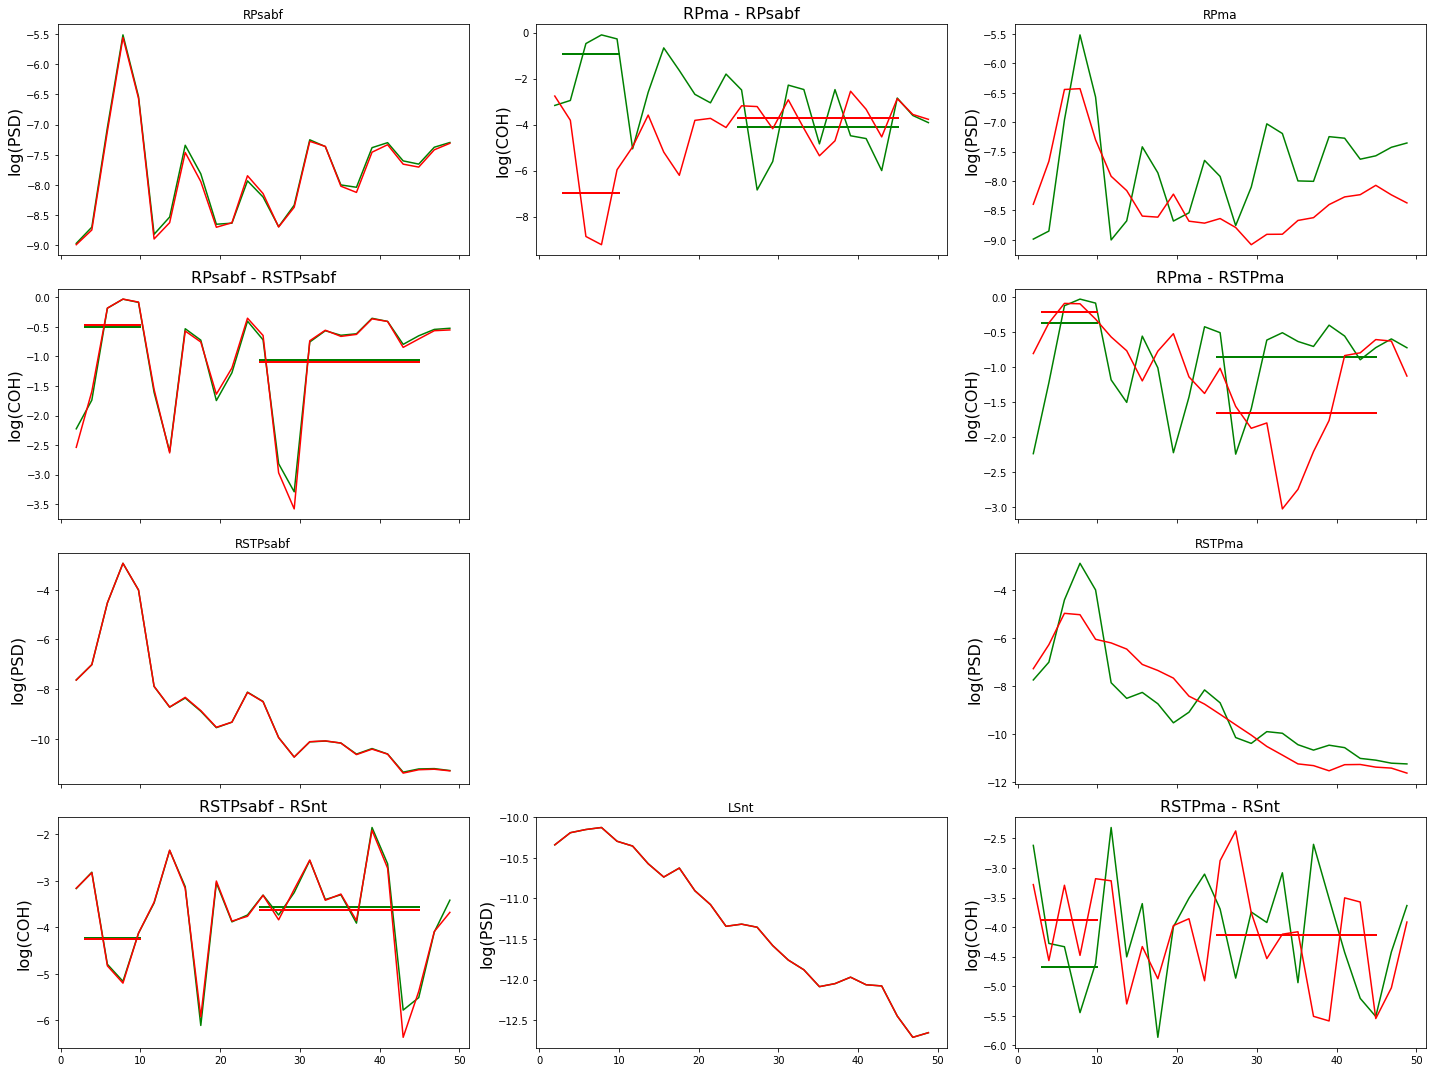

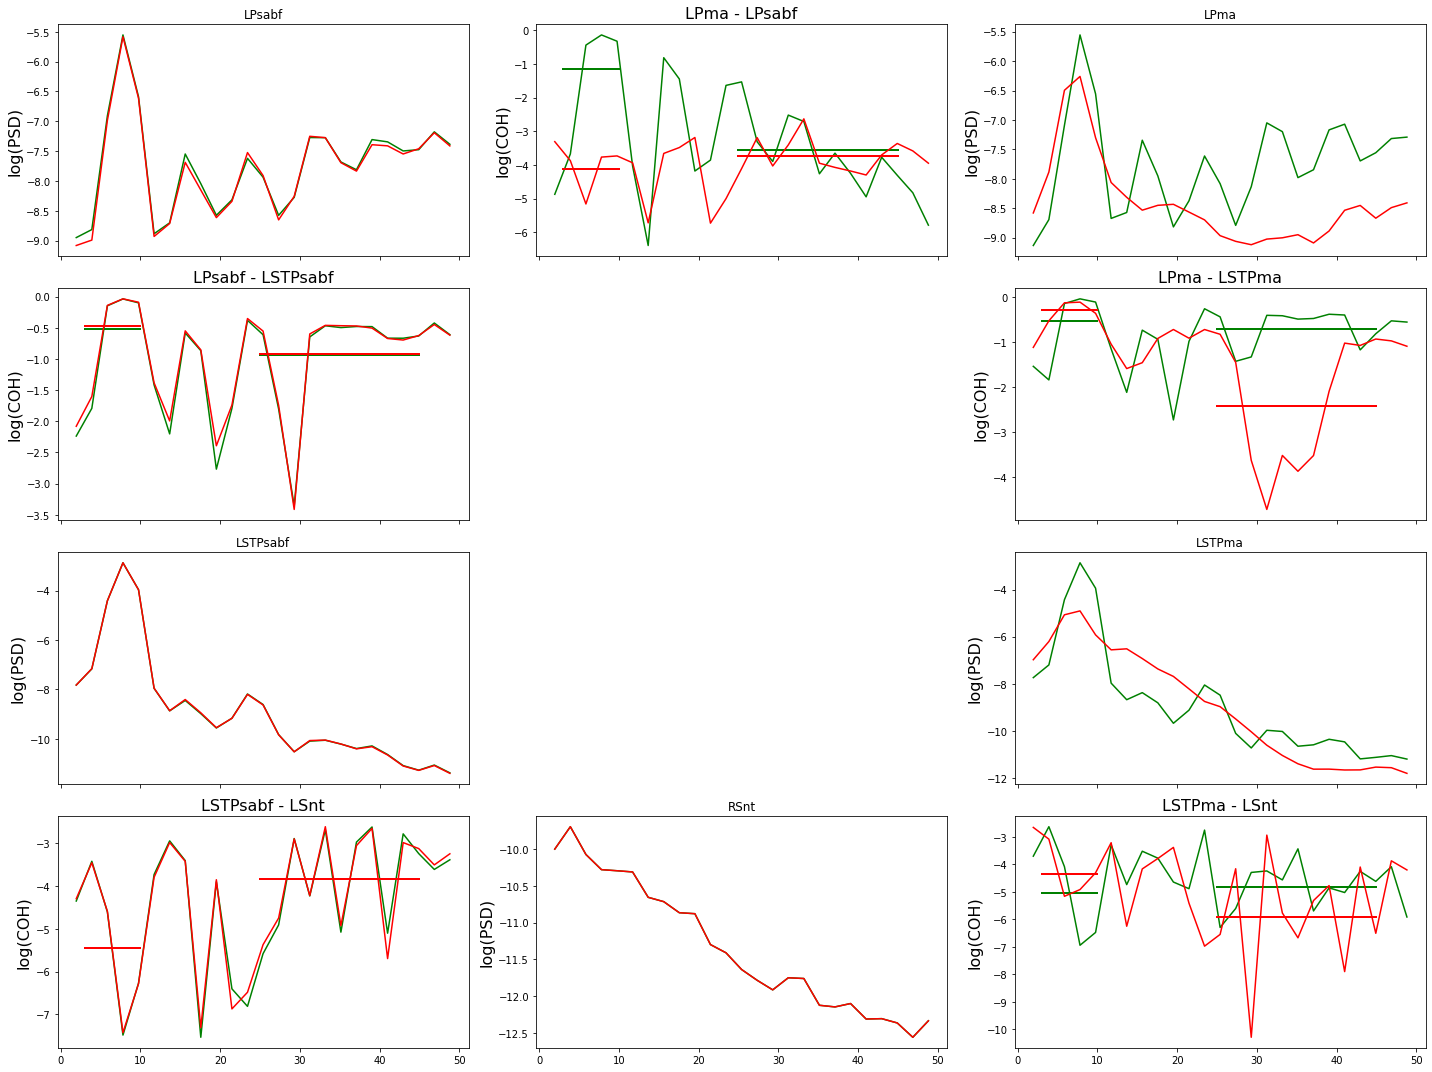

In [27]:
figR, axR, figL, axL = plot_pathway_psd_coh(
    results, newinds, 
    TRIGEMINAL=True, 
    tests=TESTS, colors=[ "g", "r"], 
    percentile_min=1, percentile_max=99, n=1,
    plot_mean=True, plot_median=False, mode="semilog",
    alpha=0.5, figsize=config.figures.LARGE_SIZE, fontsize=16)

(<Figure size 1440x3600 with 20 Axes>,
 array([[<AxesSubplot:title={'center':'Linear PSD'}, ylabel='PSD RPma'>,
         <AxesSubplot:title={'center':'Log PSD'}>],
        [<AxesSubplot:ylabel='PSD RPsabf'>, <AxesSubplot:>],
        [<AxesSubplot:ylabel='PSD RSTPma'>, <AxesSubplot:>],
        [<AxesSubplot:ylabel='PSD RSTPsabf'>, <AxesSubplot:>],
        [<AxesSubplot:ylabel='PSD RSnt'>, <AxesSubplot:>],
        [<AxesSubplot:ylabel='PSD LPma'>, <AxesSubplot:>],
        [<AxesSubplot:ylabel='PSD LPsabf'>, <AxesSubplot:>],
        [<AxesSubplot:ylabel='PSD LSTPma'>, <AxesSubplot:>],
        [<AxesSubplot:ylabel='PSD LSTPsabf'>, <AxesSubplot:>],
        [<AxesSubplot:xlabel='f (Hz)', ylabel='PSD LSnt'>,
         <AxesSubplot:xlabel='f (Hz)'>]], dtype=object))

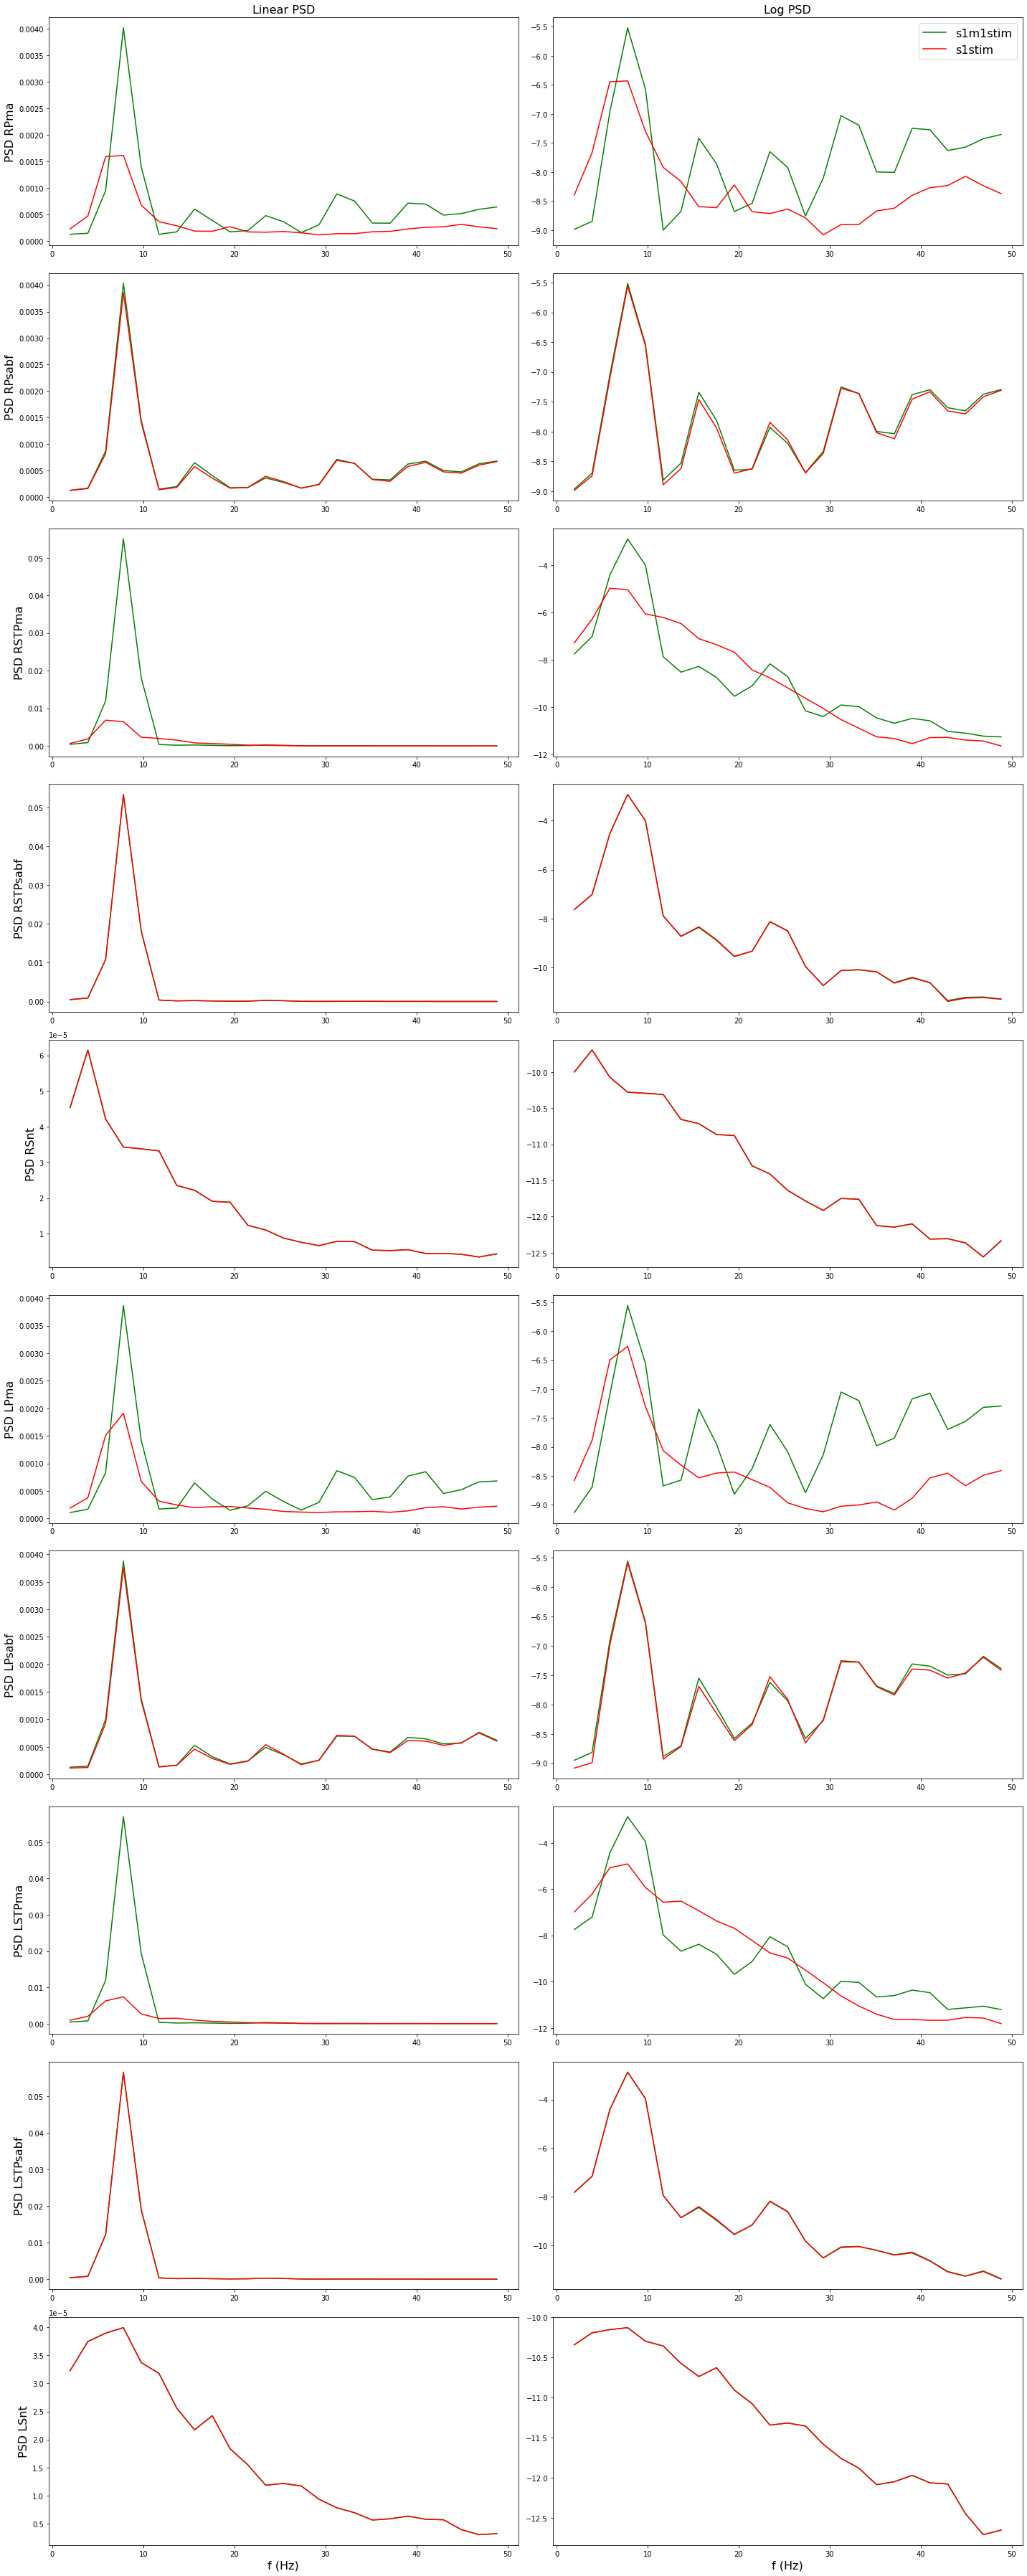

In [28]:

psd_percent_plot(results, 
                 inds=None,
                 tests=TESTS, colors=[ "g", "r"],  
                 percentile_min=1, percentile_max=99, n=1,
                 plot_mean=False, plot_median=True,
                 alpha=0.5, figsize=config.figures.DEFAULT_SIZE, fontsize=16)

(<Figure size 1440x1080 with 4 Axes>,
 array([[<AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>]], dtype=object))

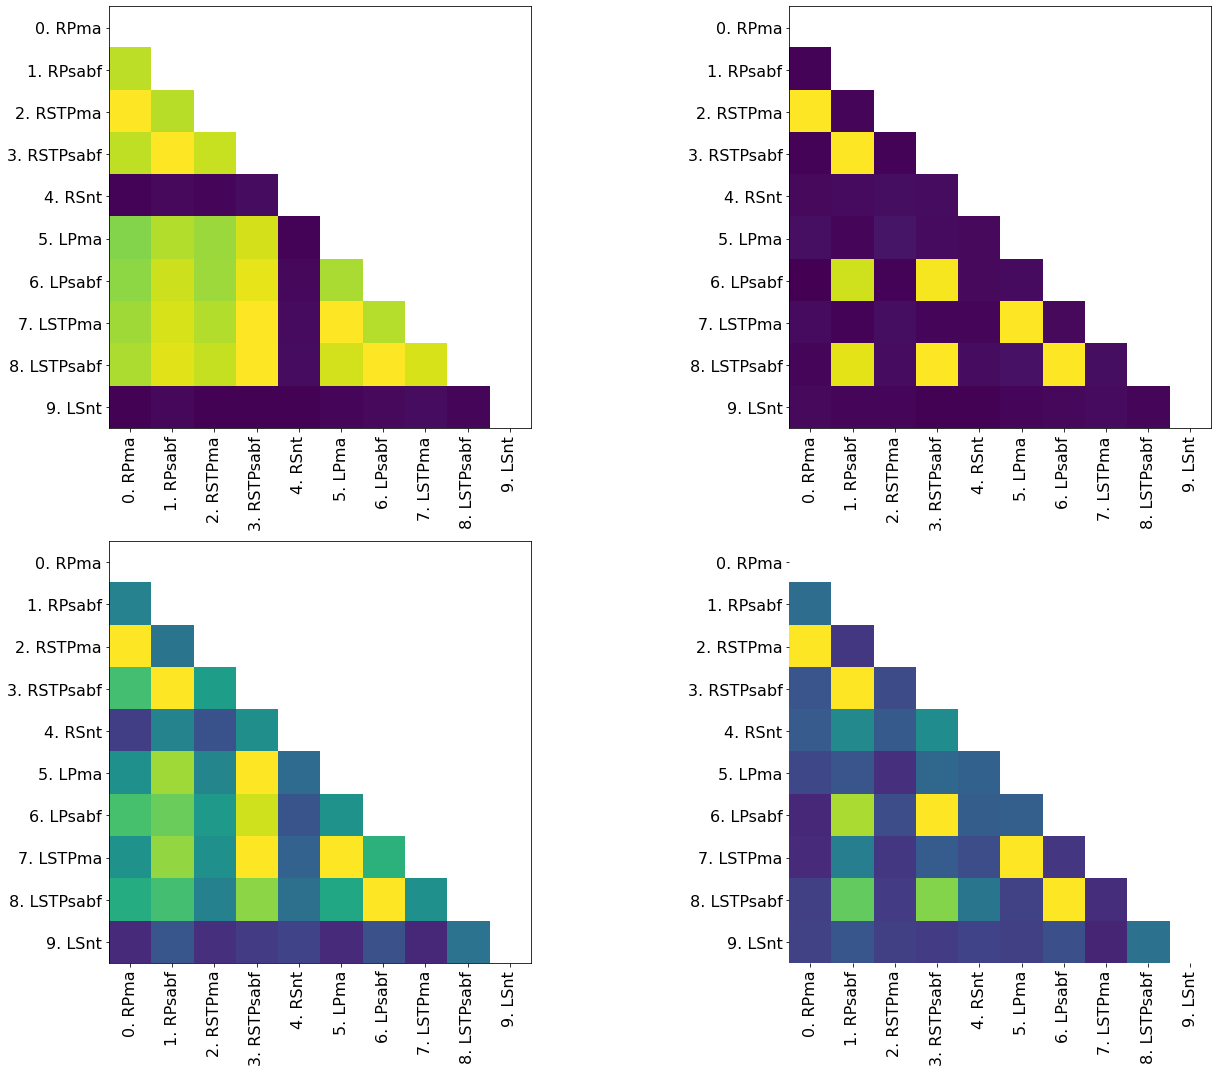

In [29]:

coherence_networks_plot(results, 
                        tests=TESTS,
                        resnames=['COHth', 'COHgm'], 
                        bands=["theta", "gamma"],
                        figsize=config.figures.DEFAULT_SIZE, fontsize=16)

In [26]:
# barplots(np.sort(inds["m1s1brl"]), "COHth", results, tests=["tvb-only", "cerebOFF"],
#          figsize=config.figures.DEFAULT_SIZE, fontsize=16, color=["g", "r"]);  # "b", 
# barplots(inds["m1s1brl"], "COHgm", results, tests=["tvb-only", "cerebOFF"],
#          figsize=config.figures.DEFAULT_SIZE, fontsize=16, color=["g", "r"])  # "b", 



In [27]:
# barplots(np.sort(inds["taskcereb"]), "COHth", results, tests=["tvb-only", "cerebOFF"],
#          figsize=config.figures.DEFAULT_SIZE, fontsize=16, color=["g", "r"])  # "b", 
# barplots(inds["taskcereb"], "COHgm", results, tests=["tvb-only", "cerebOFF"],
#          figsize=config.figures.DEFAULT_SIZE, fontsize=16, color=["g", "r"])  # "b", 